EMT columns: Index(['time', 'EfInfeed', 'PrefConverter1', 'PrefConverter2',
       'QrefConverter1', 'QrefConverter2', 'TeInfeed', 'TmInfeed',
       'deltaInfeed', 'iFault', 'iInfeedStrong_0', 'iInfeedStrong_1',
       'iInfeedStrong_2', 'iInfeedWeak_0', 'iInfeedWeak_1', 'iInfeedWeak_2',
       'iLine1_0', 'iLine1_1', 'iLine1_2', 'iLine2_0', 'iLine2_1', 'iLine2_2',
       'iLoad1_0', 'iLoad1_1', 'iLoad1_2', 'iLoad2_0', 'iLoad2_1', 'iLoad2_2',
       'idConverter1', 'idConverter2', 'iqConverter1', 'iqConverter2',
       'omegaInfeed', 'pllOutputConverter1_0', 'pllOutputConverter1_1',
       'pllOutputConverter2_0', 'pllOutputConverter2_1', 'thetaInfeed',
       'vConverter1_0', 'vConverter1_1', 'vConverter1_2', 'vConverter2_0',
       'vConverter2_1', 'vConverter2_2', 'vInfeed_0', 'vInfeed_1', 'vInfeed_2',
       'vLoad_0', 'vLoad_1', 'vLoad_2', 'vdConverter1', 'vdConverter2',
       'vqConverter1', 'vqConverter2'],
      dtype='object')
DP columns: Index(['time', 'EfInfeed', 'PrefConv

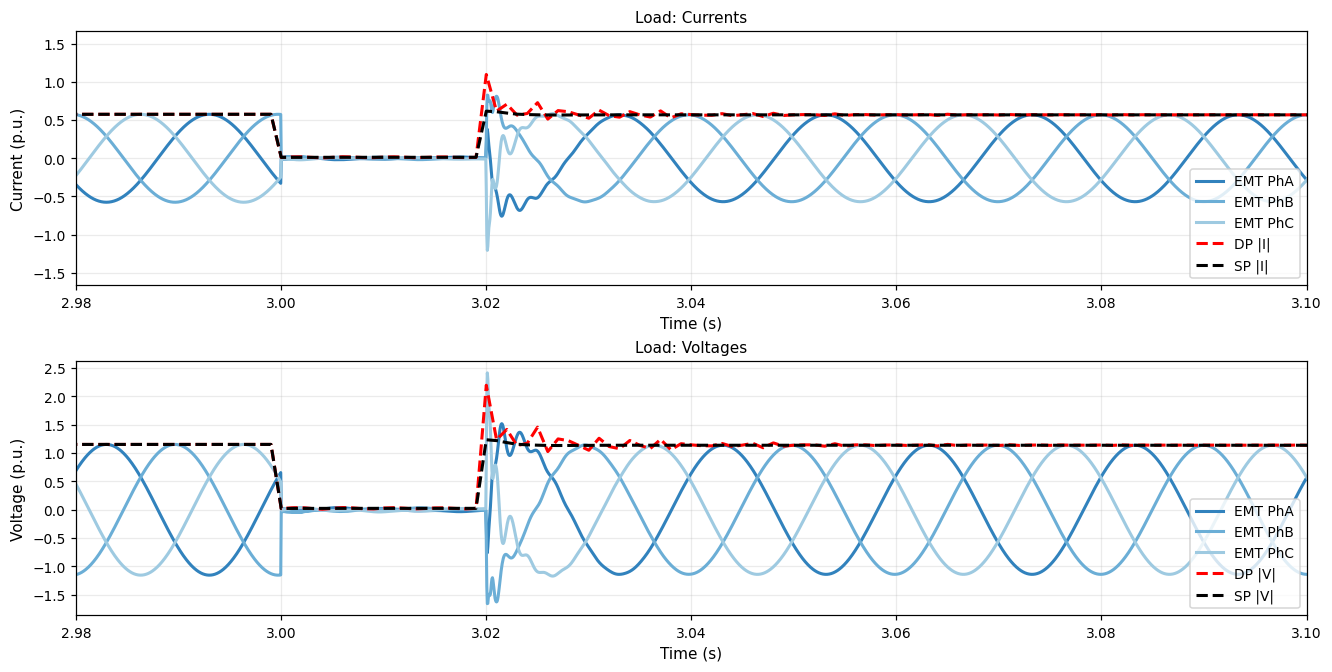

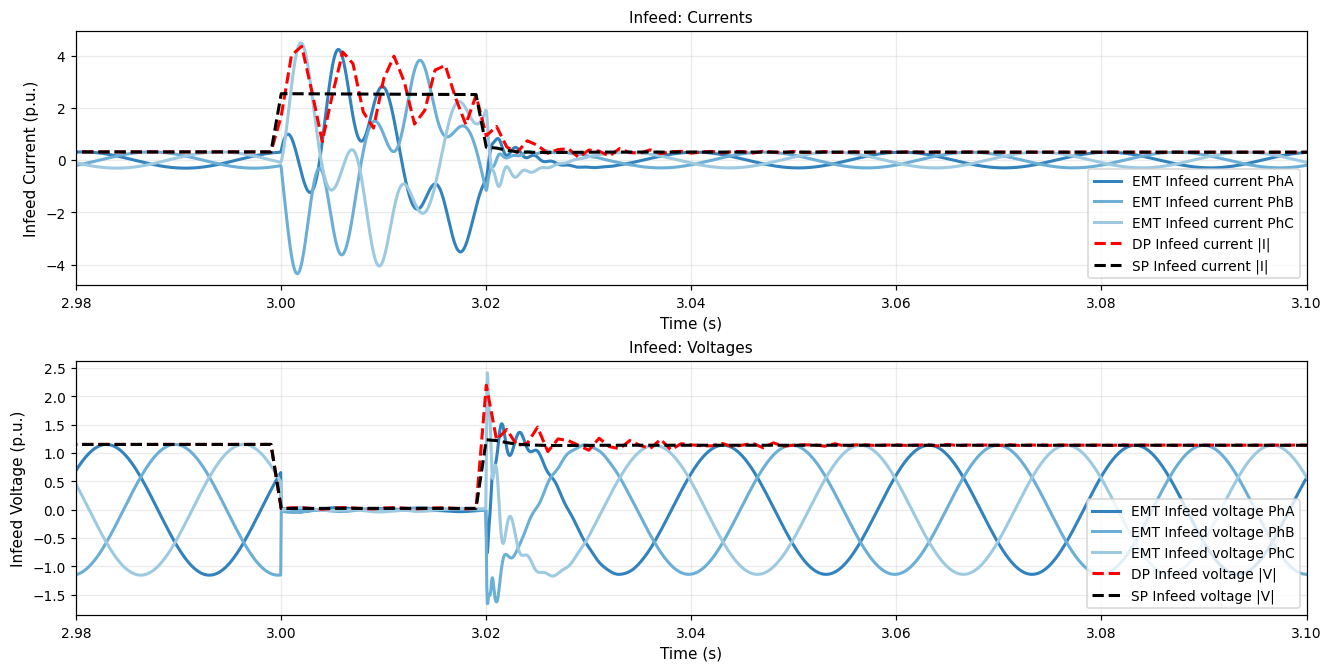

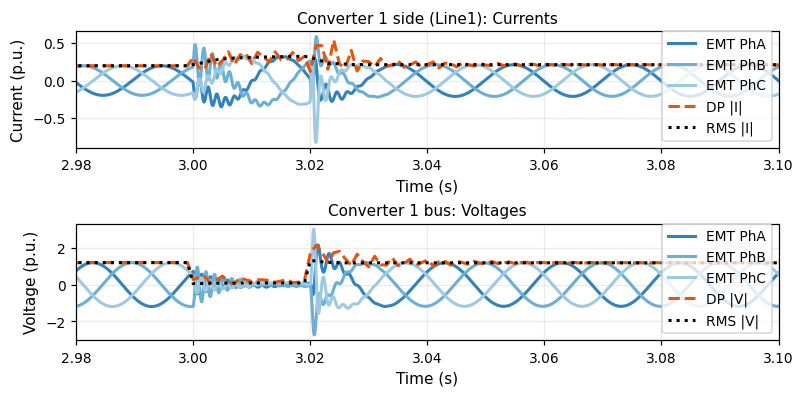

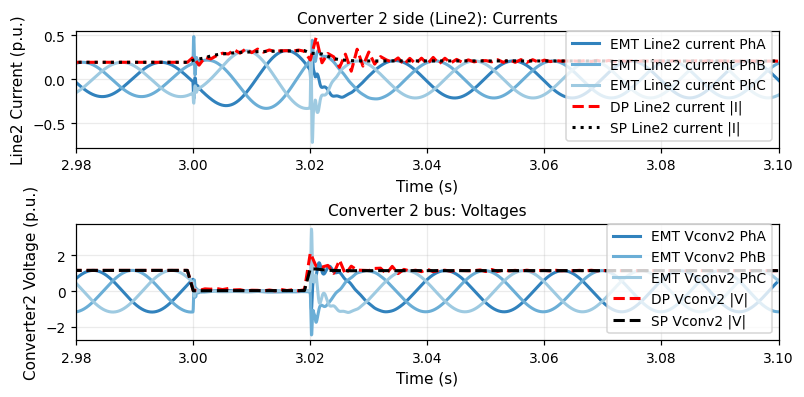

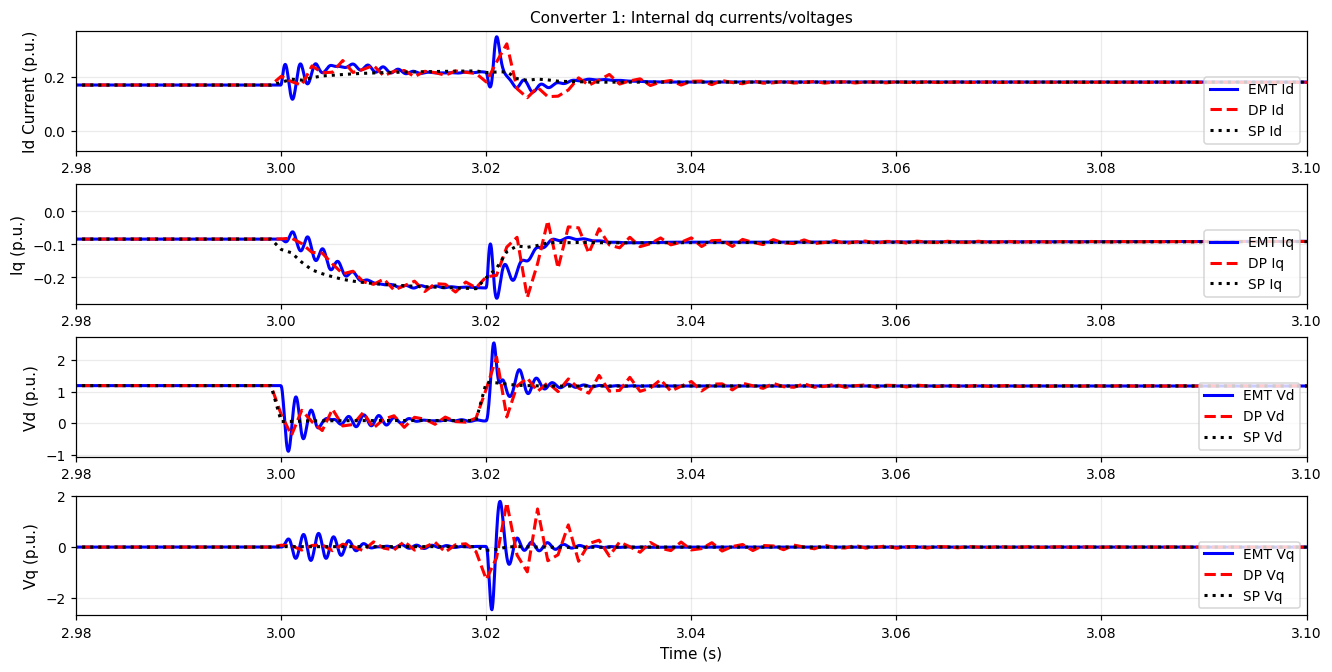

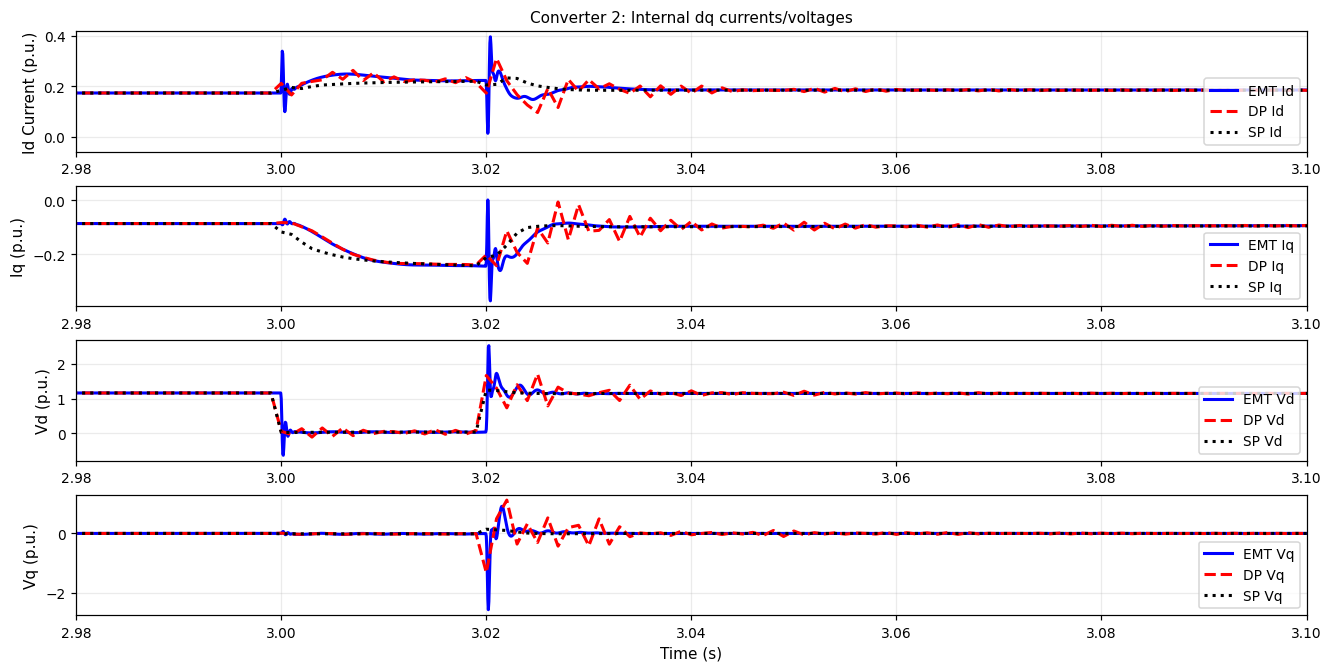

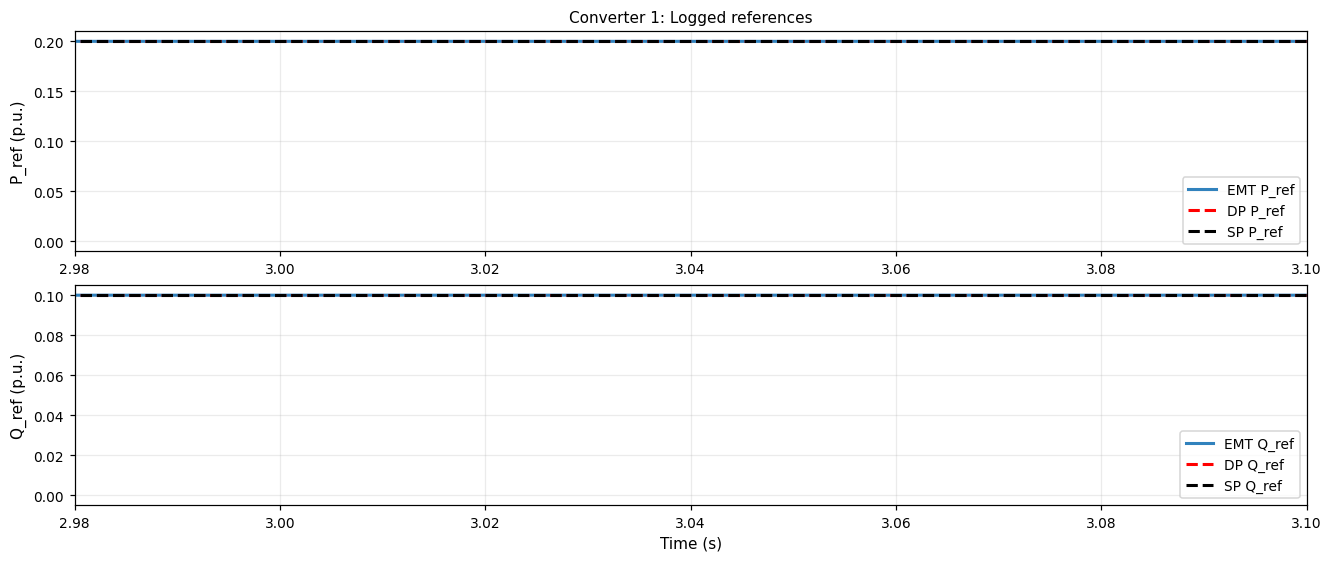

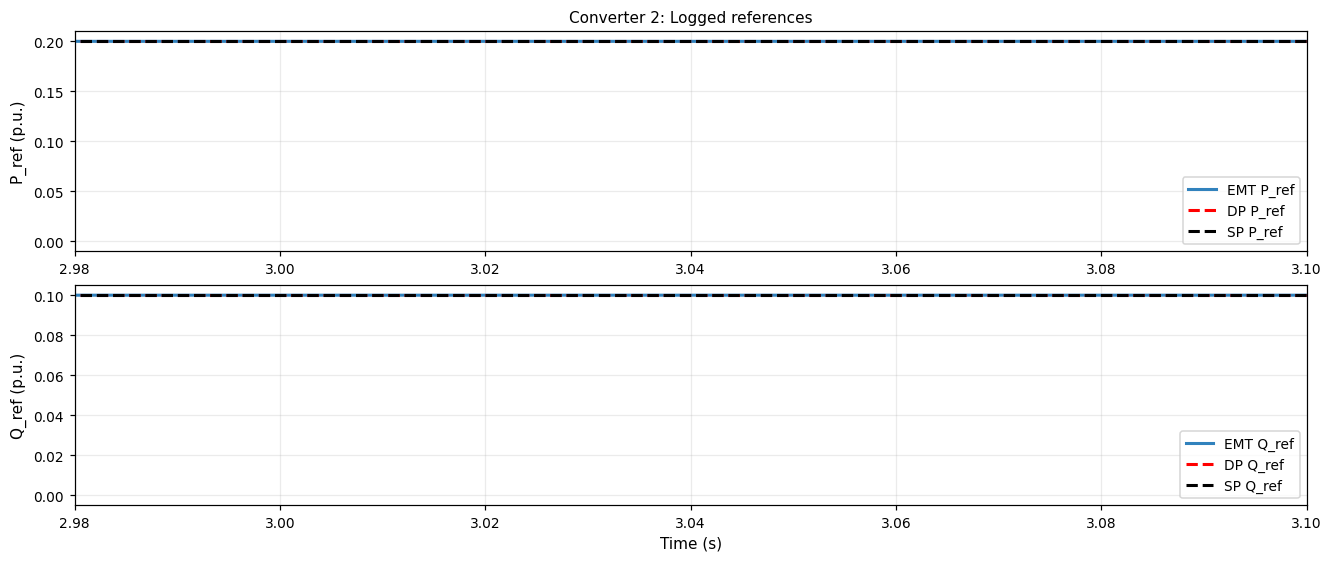

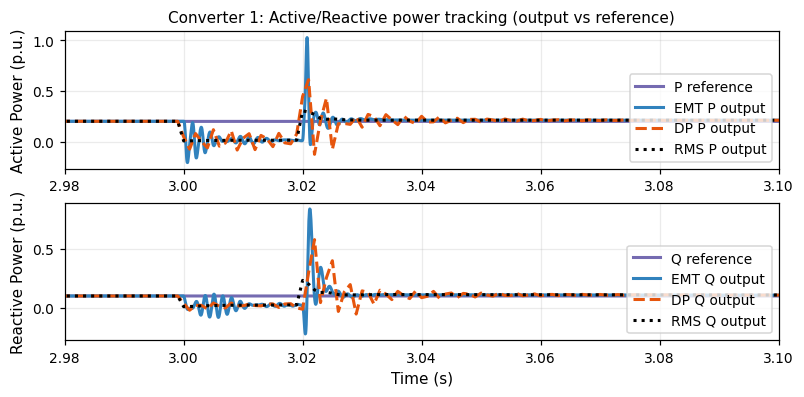

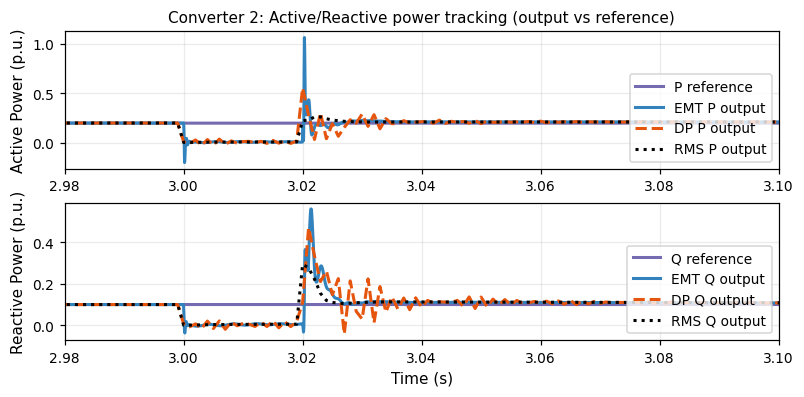

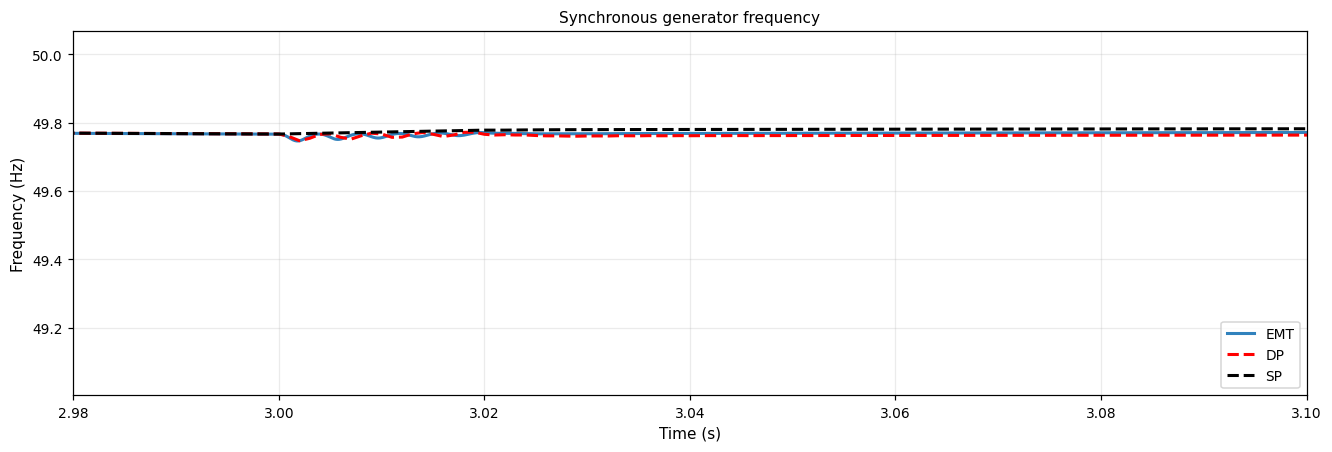

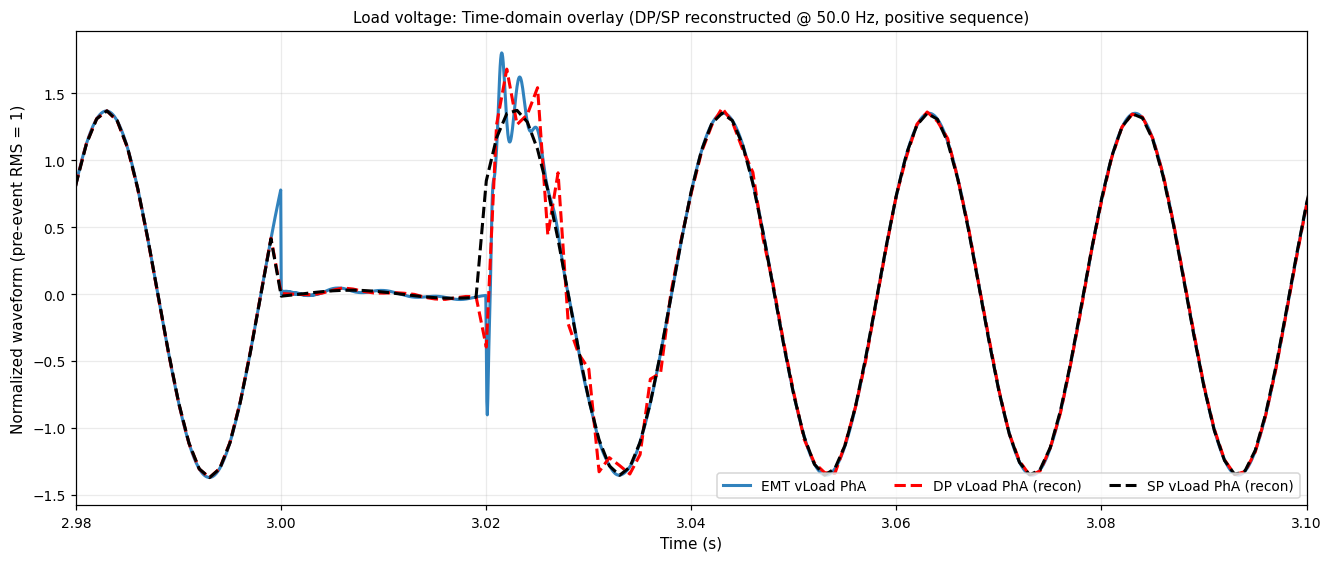

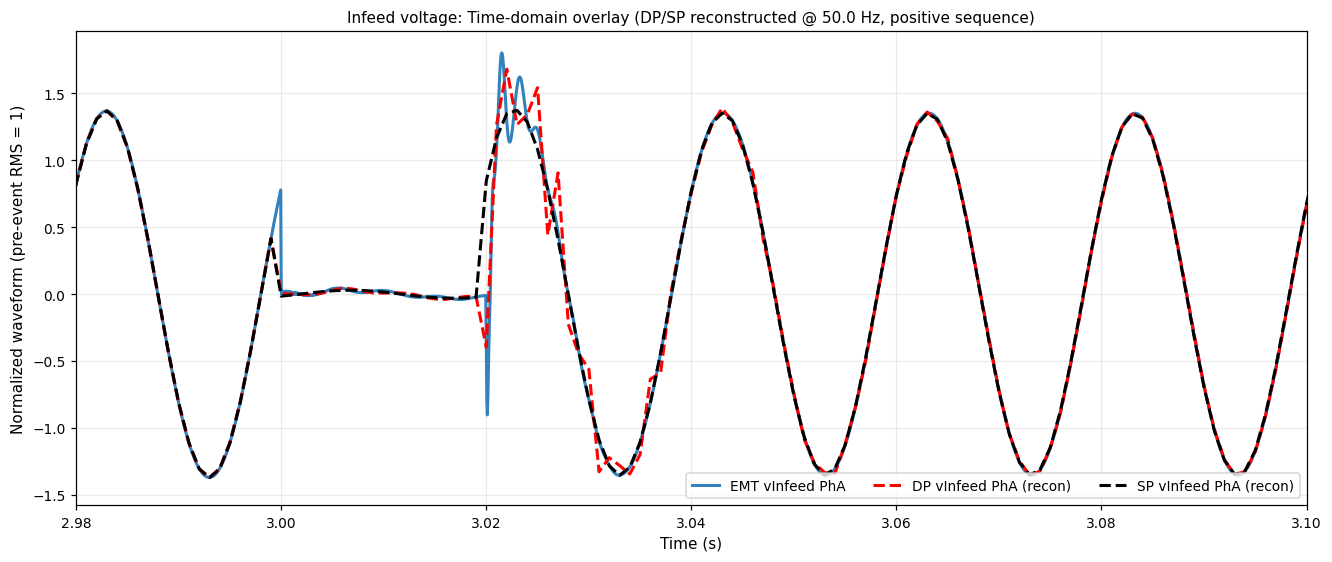

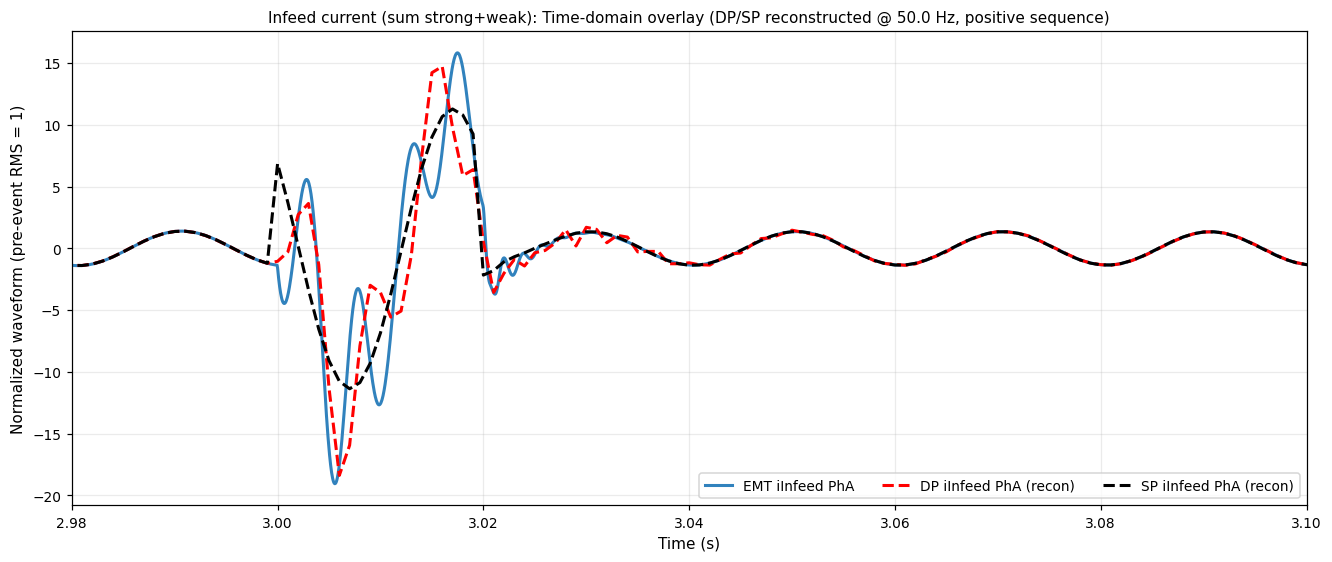

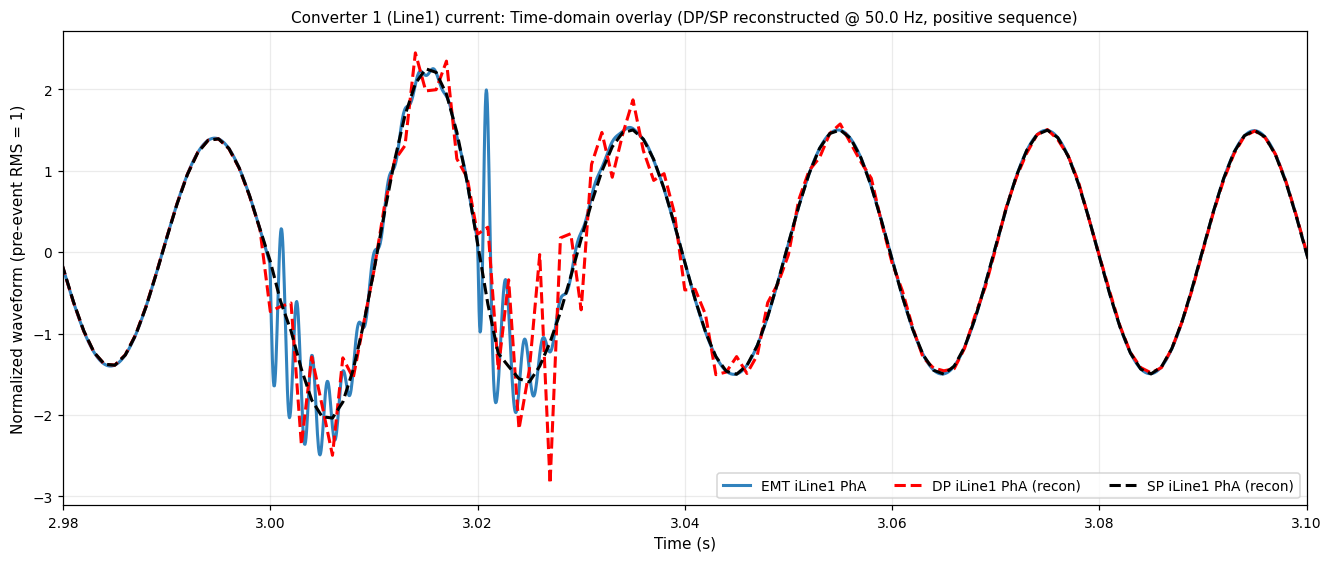

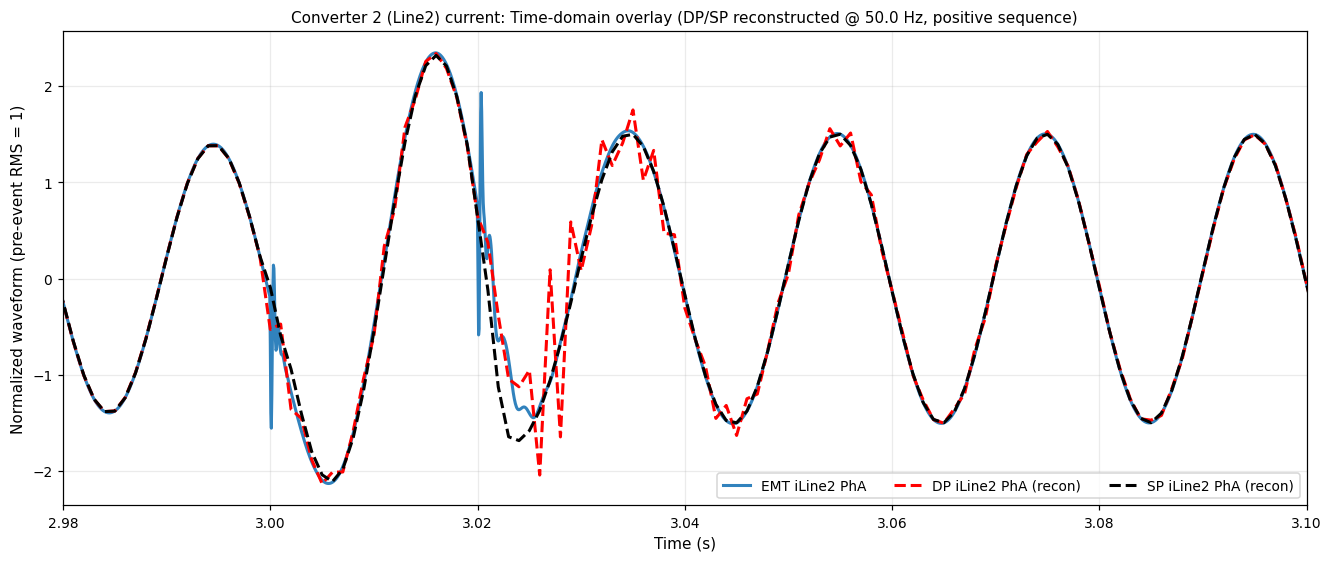

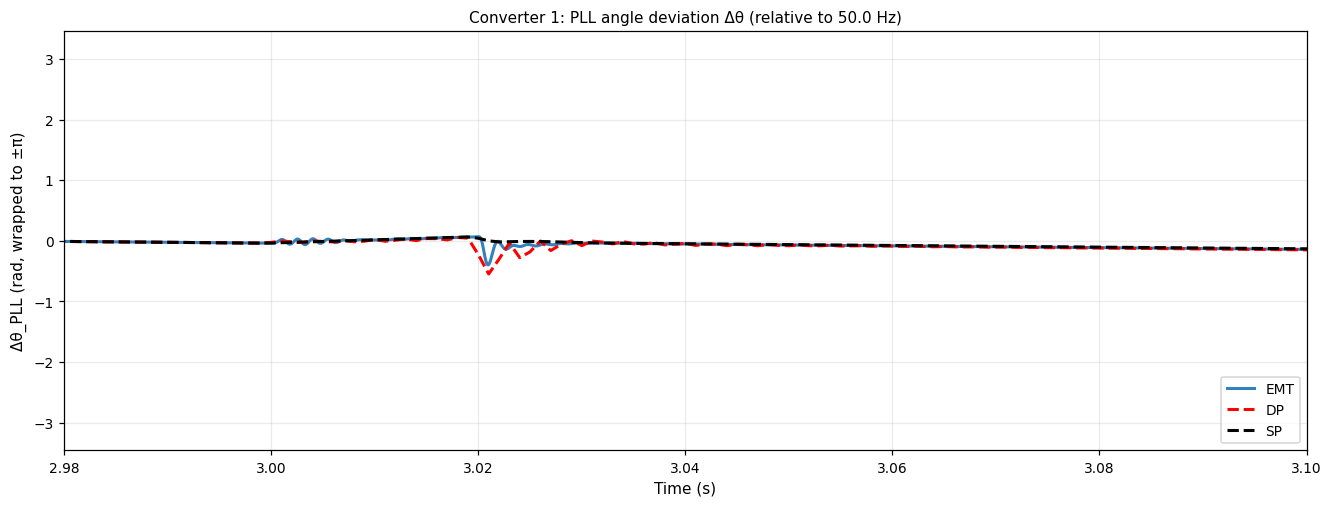

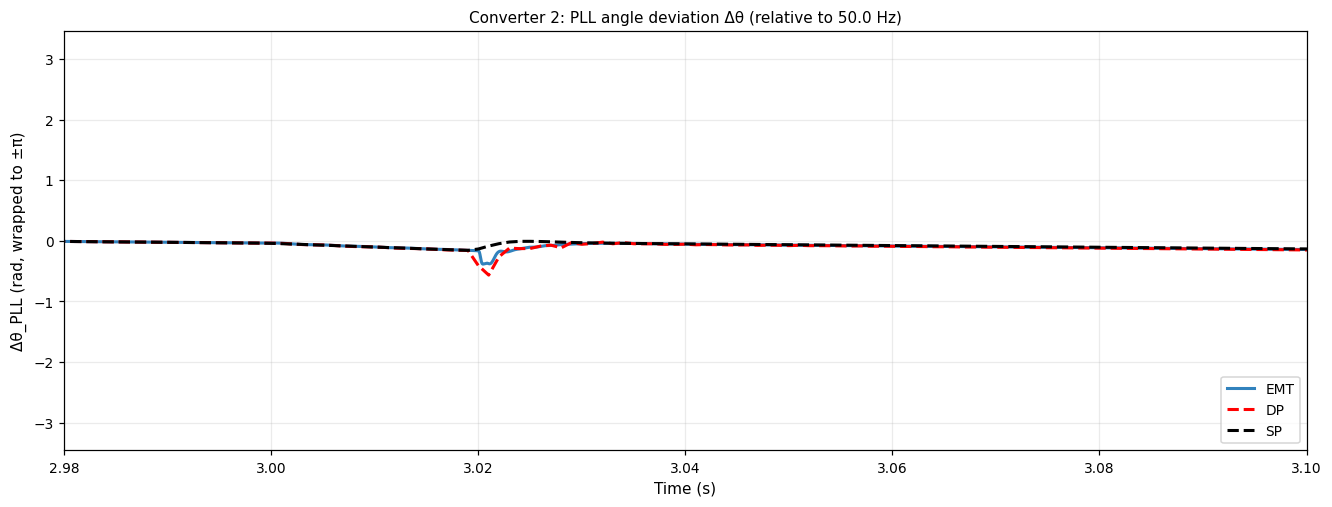

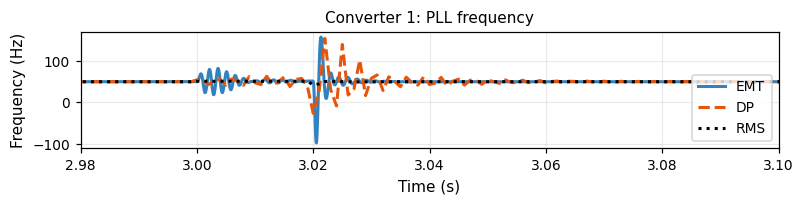

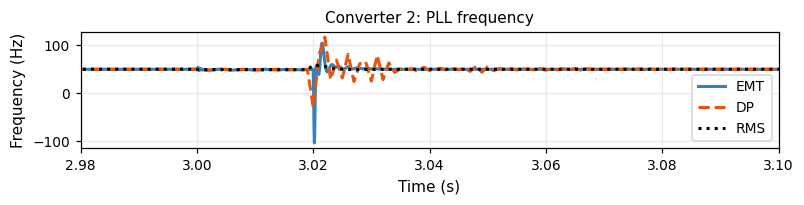

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# SciPy (allowed)
from scipy import signal
from scipy.optimize import curve_fit

# ----------------------------
# User-tunable globals
# ----------------------------
NOMINAL_FREQ_HZ = 50.0                 # DP/SP reconstruction carrier
EVENT_TIME_S    = 3.0                  # for summaries / normalization
PLOT_XLIM       = (2.98, 3.1) #(2.98, 3.02)          # GLOBAL plotted time window

# Pre-event window used for normalizing reconstructed waveforms (helps overlay scaling)
PRE_EVENT_NORM_WINDOW = (EVENT_TIME_S - 0.05, EVENT_TIME_S - 0.005)

# ----------------------------
# Infeed frequency plot selector
# ----------------------------
# Choose which infeed source you used in C++:
#   "auto"    : if omegaInfeed exists -> generator, else -> network injection
#   "network" : always plot fInfeed
#   "gen"     : always plot omegaInfeed (converted to Hz)
INFEED_SOURCE_MODE = "auto"   # "auto" | "network" | "gen"

# Column names (as logged)
F_INFEED_COL     = "fInfeed"
OMEGA_INFEED_COL = "omegaInfeed"

# If omegaInfeed is in rad/s and refers to MECHANICAL speed, electrical f = omega * pole_pairs / (2*pi).
# Default 1 is fine if omegaInfeed is already electrical rad/s (or if it is p.u., pole pairs not used).
GEN_POLE_PAIRS = 1

# ----------------------------
# OPTIONAL: Converter 3 plots
# ----------------------------
PLOT_CONVERTER3 = False  # set True if your logs include Converter3 signals

# If Converter 3 bus/line signals use different names, adjust here.
CONVERTER3_BUS_SIGNAL  = "vConverter3"
CONVERTER3_LINE_SIGNAL = "iLine3"

# ----------------------------
# NEW (3): Accuracy metrics vs EMT (time-domain)
# ----------------------------
# Evaluate accuracy in these windows
ACCURACY_PRE_WINDOW   = PRE_EVENT_NORM_WINDOW
ACCURACY_POST_WINDOW  = (EVENT_TIME_S, EVENT_TIME_S + 0.1)

# Settling-time heuristic
ACCURACY_FINAL_TAIL_S     = 0.02   # "final value" = mean over last tail of post window
ACCURACY_SETTLE_TOL_FRAC  = 0.02   # 2% of step (or baseline if step ~0)
ACCURACY_SETTLE_HOLD_S    = 0.02   # must remain within tolerance for this long

# Optionally low-pass both EMT and DP/SP magnitude traces before comparing
# (useful because DP/SP phasors don't represent switching/higher harmonics)
ACCURACY_USE_LOWPASS = False
ACCURACY_LPF_HZ      = 200.0
ACCURACY_LPF_ORDER   = 4

# Smoothing for EMT RMS magnitude extraction (envelope)
MAG_SMOOTH_WINDOW_S  = 0.002
MAG_SMOOTH_POLY      = 3

# ----------------------------
# PLL frequency from PLL state (theta, xi) + Vcq (vq)
# ----------------------------
PLL_KP = 0.25  
PLL_KI = 0.2  

# Nominal frequency used by the converter (sysOmega = 2*pi*psParams.frequency)
PLL_F0_HZ = NOMINAL_FREQ_HZ

plt.rcParams.update({
    # Typography
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,

    # Lines / markers
    "lines.linewidth": 2.0,
    "lines.markersize": 6,

    # Grid
    "axes.grid": True,
    "grid.alpha": 0.25,

    # Layout
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,  # compact without manual tight_layout()
    "axes.prop_cycle": plt.cycler(color=plt.get_cmap("tab20c").colors),
})

# ----------------------------
# 1) Load data
# ----------------------------
def load_data(path_EMT, path_DP, path_SP):
    df_EMT = pd.read_csv(path_EMT)
    df_DP  = pd.read_csv(path_DP)
    df_SP  = pd.read_csv(path_SP)

    df_EMT.columns = df_EMT.columns.str.strip()
    df_DP.columns  = df_DP.columns.str.strip()
    df_SP.columns  = df_SP.columns.str.strip()

    print("EMT columns:", df_EMT.columns)
    print("DP columns:", df_DP.columns)
    print("SP columns:", df_SP.columns)

    return df_EMT, df_DP, df_SP

# ----------------------------
# 2) Compute base parameters
# ----------------------------
def compute_base_values():
    baseVoltageLineToLine   = 110e3
    basePowerThreePhase     = 100e6
    baseCurrent             = basePowerThreePhase / baseVoltageLineToLine / np.sqrt(3)
    return baseCurrent, baseVoltageLineToLine

def compute_base_values_inverter():
    baseVoltageLineToLine   = 1500
    basePowerThreePhase     = 100e6
    baseCurrent             = basePowerThreePhase / baseVoltageLineToLine / np.sqrt(3)
    baseCurrent             = baseCurrent * np.sqrt(3)  # account for Park transformation
    return baseCurrent, baseVoltageLineToLine

def compute_base_power():
    return 100e6

# Helper: pick the first existing column name
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# ----------------------------
# NEW: Infeed current summation helpers (minimal changes)
# ----------------------------
def _get_emt_infeed_abc(df_EMT):
    """
    Returns (iA, iB, iC) for EMT infeed current.
    Supports either old single-branch logging (iInfeed_0/1/2)
    or new robust SCR logging (iInfeedStrong_0/1/2 + iInfeedWeak_0/1/2).
    """
    # New robust logging: sum strong + weak if present
    strong_cols = [f"iInfeedStrong_{k}" for k in [0, 1, 2]]
    weak_cols   = [f"iInfeedWeak_{k}"   for k in [0, 1, 2]]
    if all(c in df_EMT.columns for c in strong_cols) and all(c in df_EMT.columns for c in weak_cols):
        iA = df_EMT["iInfeedStrong_0"].to_numpy() + df_EMT["iInfeedWeak_0"].to_numpy()
        iB = df_EMT["iInfeedStrong_1"].to_numpy() + df_EMT["iInfeedWeak_1"].to_numpy()
        iC = df_EMT["iInfeedStrong_2"].to_numpy() + df_EMT["iInfeedWeak_2"].to_numpy()
        return iA, iB, iC

    # Old logging: single infeed current
    old_cols = [f"iInfeed_{k}" for k in [0, 1, 2]]
    if all(c in df_EMT.columns for c in old_cols):
        return (df_EMT["iInfeed_0"].to_numpy(),
                df_EMT["iInfeed_1"].to_numpy(),
                df_EMT["iInfeed_2"].to_numpy())

    return None, None, None

def get_complex_phasor_sum(df, base_names):
    """
    Sum multiple phasor signals (each stored as .re/.im) into one complex phasor.
    Returns None if any constituent is missing.
    """
    Xsum = None
    for name in base_names:
        X = get_complex_phasor(df, name)
        if X is None:
            return None
        Xsum = X if Xsum is None else (Xsum + X)
    return Xsum

# ----------------------------
# DP/SP phasor helpers + 3-phase reconstruction (positive sequence)
# ----------------------------
def get_complex_phasor(df, base_name):
    re_col = pick_col(df, [f"{base_name}.re", f"{base_name}_re", f"{base_name}.real"])
    im_col = pick_col(df, [f"{base_name}.im", f"{base_name}_im", f"{base_name}.imag"])
    if re_col is None or im_col is None:
        return None
    return df[re_col].to_numpy() + 1j * df[im_col].to_numpy()

def reconstruct_abc_from_phasor(t, X, freq_hz=NOMINAL_FREQ_HZ, rms_phasor=True):
    """
    Reconstruct 3-phase time-domain waveforms from a single complex phasor X(t)
    assuming positive sequence.

    If X is RMS phasor, multiply by sqrt(2) to obtain peak waveform.
    """
    if X is None:
        return None, None, None
    scale = np.sqrt(2) if rms_phasor else 1.0
    wt = 2 * np.pi * freq_hz * t
    shift_b = -2 * np.pi / 3
    shift_c = +2 * np.pi / 3
    va = scale * np.real(X * np.exp(1j * (wt + 0.0)))
    vb = scale * np.real(X * np.exp(1j * (wt + shift_b)))
    vc = scale * np.real(X * np.exp(1j * (wt + shift_c)))
    return va, vb, vc

def rms_in_window(t, x, t0, t1):
    m = (t >= t0) & (t <= t1)
    if np.sum(m) < 5:
        return None
    return np.sqrt(np.mean(x[m] ** 2))

def normalize_by_pre_event_rms(t, x, window=PRE_EVENT_NORM_WINDOW):
    r = rms_in_window(t, x, window[0], window[1])
    if r is None or r <= 0:
        return x
    return x / r

def plot_reconstructed_overlay_abc(df_EMT, df_DP, df_SP, signal_base, equipment_label,
                                  freq_hz=NOMINAL_FREQ_HZ, xlim=PLOT_XLIM, normalize=True):
    """
    Time-domain overlay for all 3 phases in ONE plot:
      EMT: uses *_0,_1,_2 instantaneous
      DP/SP: reconstructs abc from single phasor assuming positive sequence

    Minimal change: if signal_base == "iInfeed", we use summed infeed current
    (strong+weak) when available.
    """
    t_emt = df_EMT["time"].to_numpy()
    t_dp  = df_DP["time"].to_numpy()
    t_sp  = df_SP["time"].to_numpy()

    # EMT abc
    if signal_base == "iInfeed":
        emt_a, emt_b, emt_c = _get_emt_infeed_abc(df_EMT)
        if emt_a is None:
            print(f"[WARN] EMT missing infeed current columns (old or strong/weak) for overlay.")
            return
    else:
        ca, cb, cc = f"{signal_base}_0", f"{signal_base}_1", f"{signal_base}_2"
        if not all(c in df_EMT.columns for c in [ca, cb, cc]):
            print(f"[WARN] EMT missing abc columns for {signal_base} ({equipment_label}): {ca},{cb},{cc}")
            return
        emt_a = df_EMT[ca].to_numpy()
        emt_b = df_EMT[cb].to_numpy()
        emt_c = df_EMT[cc].to_numpy()

    # DP/SP phasors
    if signal_base == "iInfeed":
        # Prefer summed strong+weak if present, else fall back to legacy iInfeed
        X_dp = get_complex_phasor_sum(df_DP, ["iInfeedStrong", "iInfeedWeak"])
        X_sp = get_complex_phasor_sum(df_SP, ["iInfeedStrong", "iInfeedWeak"])
        if X_dp is None or X_sp is None:
            X_dp = get_complex_phasor(df_DP, "iInfeed")
            X_sp = get_complex_phasor(df_SP, "iInfeed")
    else:
        X_dp = get_complex_phasor(df_DP, signal_base)
        X_sp = get_complex_phasor(df_SP, signal_base)

    if X_dp is None or X_sp is None:
        print(f"[WARN] DP/SP missing phasor columns for {signal_base} ({equipment_label}).")
        return

    dp_a, dp_b, dp_c = reconstruct_abc_from_phasor(t_dp, X_dp, freq_hz=freq_hz, rms_phasor=True)
    sp_a, sp_b, sp_c = reconstruct_abc_from_phasor(t_sp, X_sp, freq_hz=freq_hz, rms_phasor=True)

    if normalize:
        emt_a = normalize_by_pre_event_rms(t_emt, emt_a)
        emt_b = normalize_by_pre_event_rms(t_emt, emt_b)
        emt_c = normalize_by_pre_event_rms(t_emt, emt_c)
        dp_a  = normalize_by_pre_event_rms(t_dp,  dp_a)
        dp_b  = normalize_by_pre_event_rms(t_dp,  dp_b)
        dp_c  = normalize_by_pre_event_rms(t_dp,  dp_c)
        sp_a  = normalize_by_pre_event_rms(t_sp,  sp_a)
        sp_b  = normalize_by_pre_event_rms(t_sp,  sp_b)
        sp_c  = normalize_by_pre_event_rms(t_sp,  sp_c)
        ylab = "Normalized waveform (pre-event RMS = 1)"
    else:
        ylab = "Instantaneous waveform (native units)"

    plt.figure(figsize=(12, 5))
    plt.grid(True)
    plt.title(f"{equipment_label}: Time-domain overlay (DP/SP reconstructed @ {freq_hz} Hz, positive sequence)")

    plt.plot(t_emt, emt_a, label=f"EMT {signal_base} PhA")
    # plt.plot(t_emt, emt_b, label=f"EMT {signal_base} PhB")
    # plt.plot(t_emt, emt_c, label=f"EMT {signal_base} PhC")

    plt.plot(t_dp, dp_a, "r--", label=f"DP {signal_base} PhA (recon)")
    # plt.plot(t_dp, dp_b, "r--", label=f"DP {signal_base} PhB (recon)")
    # plt.plot(t_dp, dp_c, "r--", label=f"DP {signal_base} PhC (recon)")

    plt.plot(t_sp, sp_a, "k--", label=f"SP {signal_base} PhA (recon)")
    # plt.plot(t_sp, sp_b, "k--", label=f"SP {signal_base} PhB (recon)")
    # plt.plot(t_sp, sp_c, "k--", label=f"SP {signal_base} PhC (recon)")

    plt.xlabel("Time (s)")
    plt.ylabel(ylab)
    plt.xlim(*xlim)
    plt.legend(loc="lower right", ncol=3)

# ----------------------------
# Equipment plots (using global PLOT_XLIM)
# ----------------------------
def plot_load(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage, xlim=PLOT_XLIM):
    plt.figure(1, figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.grid(True)
    EMT_load_I0 = (df_EMT['iLoad1_0'] + df_EMT['iLoad2_0']) / baseCurrent / np.sqrt(2)
    EMT_load_I1 = (df_EMT['iLoad1_1'] + df_EMT['iLoad2_1']) / baseCurrent / np.sqrt(2)
    EMT_load_I2 = (df_EMT['iLoad1_2'] + df_EMT['iLoad2_2']) / baseCurrent / np.sqrt(2)
    plt.plot(df_EMT['time'], EMT_load_I0, label='EMT PhA')
    plt.plot(df_EMT['time'], EMT_load_I1, label='EMT PhB')
    plt.plot(df_EMT['time'], EMT_load_I2, label='EMT PhC')

    Iload_DP = np.abs((df_DP['iLoad1.re'] + df_DP['iLoad2.re']) + 1j*(df_DP['iLoad1.im'] + df_DP['iLoad2.im'])) / baseCurrent / np.sqrt(3)
    Iload_SP = np.abs((df_SP['iLoad1.re'] + df_SP['iLoad2.re']) + 1j*(df_SP['iLoad1.im'] + df_SP['iLoad2.im'])) / baseCurrent / np.sqrt(3)
    plt.plot(df_DP['time'], Iload_DP, 'r--', label='DP |I|')
    plt.plot(df_SP['time'], Iload_SP, 'k--', label='SP |I|')
    plt.xlabel('Time (s)')
    plt.ylabel('Current (p.u.)')
    plt.xlim(*xlim)
    plt.title("Load: Currents")
    plt.legend(loc='lower right')

    plt.subplot(2, 1, 2)
    plt.grid(True)
    v0 = df_EMT['vLoad_0'] / baseVoltage * np.sqrt(3) / np.sqrt(2)
    v1 = df_EMT['vLoad_1'] / baseVoltage * np.sqrt(3) / np.sqrt(2)
    v2 = df_EMT['vLoad_2'] / baseVoltage * np.sqrt(3) / np.sqrt(2)
    plt.plot(df_EMT['time'], v0, label='EMT PhA')
    plt.plot(df_EMT['time'], v1, label='EMT PhB')
    plt.plot(df_EMT['time'], v2, label='EMT PhC')

    Vload_DP = np.abs(df_DP['vLoad.re'] + 1j*df_DP['vLoad.im']) / baseVoltage
    Vload_SP = np.abs(df_SP['vLoad.re'] + 1j*df_SP['vLoad.im']) / baseVoltage
    plt.plot(df_DP['time'], Vload_DP, 'r--', label='DP |V|')
    plt.plot(df_SP['time'], Vload_SP, 'k--', label='SP |V|')
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage (p.u.)')
    plt.xlim(*xlim)
    plt.title("Load: Voltages")
    plt.legend(loc='lower right')

def plot_infeed(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage, xlim=PLOT_XLIM):
    plt.figure(2, figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.grid(True)

    # EMT: sum strong+weak if present; otherwise fallback to legacy iInfeed_*
    emt_a, emt_b, emt_c = _get_emt_infeed_abc(df_EMT)
    if emt_a is None:
        print("[WARN] EMT missing infeed current columns (old or strong/weak).")
        return

    plt.plot(df_EMT['time'], -emt_a / baseCurrent / np.sqrt(2), label='EMT Infeed current PhA')
    plt.plot(df_EMT['time'], -emt_b / baseCurrent / np.sqrt(2), label='EMT Infeed current PhB')
    plt.plot(df_EMT['time'], -emt_c / baseCurrent / np.sqrt(2), label='EMT Infeed current PhC')

    # DP/SP: use summed phasor if present; else fallback to legacy iInfeed
    Xdp = get_complex_phasor_sum(df_DP, ["iInfeedStrong", "iInfeedWeak"])
    Xsp = get_complex_phasor_sum(df_SP, ["iInfeedStrong", "iInfeedWeak"])
    if Xdp is None or Xsp is None:
        Xdp = get_complex_phasor(df_DP, "iInfeed")
        Xsp = get_complex_phasor(df_SP, "iInfeed")

    if Xdp is None or Xsp is None:
        print("[WARN] DP/SP missing infeed current phasors (strong/weak sum or legacy iInfeed).")
        return

    Iinf_DP = np.abs(Xdp) / baseCurrent / np.sqrt(3)
    Iinf_SP = np.abs(Xsp) / baseCurrent / np.sqrt(3)
    plt.plot(df_DP['time'], Iinf_DP, 'r--', label='DP Infeed current |I|')
    plt.plot(df_SP['time'], Iinf_SP, 'k--', label='SP Infeed current |I|')
    plt.xlabel('Time (s)')
    plt.ylabel('Infeed Current (p.u.)')
    plt.xlim(*xlim)
    plt.title("Infeed: Currents")
    plt.legend(loc='lower right')

    plt.subplot(2, 1, 2)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT['vInfeed_0']/baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT Infeed voltage PhA')
    plt.plot(df_EMT['time'], df_EMT['vInfeed_1']/baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT Infeed voltage PhB')
    plt.plot(df_EMT['time'], df_EMT['vInfeed_2']/baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT Infeed voltage PhC')

    Vinf_DP = np.abs(df_DP['vInfeed.re'] + 1j * df_DP['vInfeed.im']) / baseVoltage
    Vinf_SP = np.abs(df_SP['vInfeed.re'] + 1j * df_SP['vInfeed.im']) / baseVoltage
    plt.plot(df_DP['time'], Vinf_DP, 'r--', label='DP Infeed voltage |V|')
    plt.plot(df_SP['time'], Vinf_SP, 'k--', label='SP Infeed voltage |V|')
    plt.xlabel('Time (s)')
    plt.ylabel('Infeed Voltage (p.u.)')
    plt.xlim(*xlim)
    plt.title("Infeed: Voltages")
    plt.legend(loc='lower right')

def plot_converter1(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage, xlim=PLOT_XLIM):
    plt.figure(3, figsize=(7.2, 3.5))
    plt.subplot(2, 1, 1)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT['iLine1_0'] / baseCurrent / np.sqrt(2), label='EMT PhA')
    plt.plot(df_EMT['time'], df_EMT['iLine1_1'] / baseCurrent / np.sqrt(2), label='EMT PhB')
    plt.plot(df_EMT['time'], df_EMT['iLine1_2'] / baseCurrent / np.sqrt(2), label='EMT PhC')

    I1_DP = np.abs(df_DP['iLine1.re'] + 1j * df_DP['iLine1.im']) / baseCurrent / np.sqrt(3)
    I1_SP = np.abs(df_SP['iLine1.re'] + 1j * df_SP['iLine1.im']) / baseCurrent / np.sqrt(3)
    plt.plot(df_DP['time'], I1_DP, color="C4", ls="--", label='DP |I|')
    plt.plot(df_SP['time'], I1_SP, 'k:', label='RMS |I|')
    plt.xlabel('Time (s)')
    plt.ylabel('Current (p.u.)')
    plt.xlim(*xlim)
    #plt.ylim(-2, 10)
    plt.title("Converter 1 side (Line1): Currents")
    plt.legend(loc='lower right')

    
    plt.subplot(2, 1, 2)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT['vConverter1_0'] / baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT PhA')
    plt.plot(df_EMT['time'], df_EMT['vConverter1_1'] / baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT PhB')
    plt.plot(df_EMT['time'], df_EMT['vConverter1_2'] / baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT PhC')

    V1_DP = np.abs(df_DP['vConverter1.re'] + 1j * df_DP['vConverter1.im']) / baseVoltage
    V1_SP = np.abs(df_SP['vConverter1.re'] + 1j * df_SP['vConverter1.im']) / baseVoltage
    plt.plot(df_DP['time'], V1_DP, color="C4", ls="--", label='DP |V|')
    plt.plot(df_SP['time'], V1_SP, 'k:', label='RMS |V|')
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage (p.u.)')
    plt.xlim(*xlim)
    #plt.ylim(-3, 10)
    plt.title("Converter 1 bus: Voltages")
    plt.legend(loc='lower right')

def plot_converter2(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage, xlim=PLOT_XLIM):
    plt.figure(4, figsize=(7.2, 3.5))
    plt.subplot(2, 1, 1)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT['iLine2_0'] / baseCurrent / np.sqrt(2), label='EMT Line2 current PhA')
    plt.plot(df_EMT['time'], df_EMT['iLine2_1'] / baseCurrent / np.sqrt(2), label='EMT Line2 current PhB')
    plt.plot(df_EMT['time'], df_EMT['iLine2_2'] / baseCurrent / np.sqrt(2), label='EMT Line2 current PhC')

    I2_DP = np.abs(df_DP['iLine2.re'] + 1j * df_DP['iLine2.im']) / baseCurrent / np.sqrt(3)
    I2_SP = np.abs(df_SP['iLine2.re'] + 1j * df_SP['iLine2.im']) / baseCurrent / np.sqrt(3)
    plt.plot(df_DP['time'], I2_DP, 'r--', label='DP Line2 current |I|')
    plt.plot(df_SP['time'], I2_SP, 'k:', label='SP Line2 current |I|')
    plt.xlabel('Time (s)')
    plt.ylabel('Line2 Current (p.u.)')
    plt.xlim(*xlim)
    plt.title("Converter 2 side (Line2): Currents")
    plt.legend(loc='lower right')

    plt.subplot(2, 1, 2)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT['vConverter2_0'] / baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT Vconv2 PhA')
    plt.plot(df_EMT['time'], df_EMT['vConverter2_1'] / baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT Vconv2 PhB')
    plt.plot(df_EMT['time'], df_EMT['vConverter2_2'] / baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT Vconv2 PhC')

    V2_DP = np.abs(df_DP['vConverter2.re'] + 1j * df_DP['vConverter2.im']) / baseVoltage
    V2_SP = np.abs(df_SP['vConverter2.re'] + 1j * df_SP['vConverter2.im']) / baseVoltage
    plt.plot(df_DP['time'], V2_DP, 'r--', label='DP Vconv2 |V|')
    plt.plot(df_SP['time'], V2_SP, 'k--', label='SP Vconv2 |V|')
    plt.xlabel('Time (s)')
    plt.ylabel('Converter2 Voltage (p.u.)')
    plt.xlim(*xlim)
    plt.title("Converter 2 bus: Voltages")
    plt.legend(loc='lower right')

def plot_converter_internal_vars(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage, conv_idx, xlim=PLOT_XLIM):
    # keep old numbering for conv1/2; avoid collisions if conv3 is enabled
    fig_num = (4 + conv_idx) if conv_idx <= 2 else (40 + conv_idx)
    plt.figure(fig_num, figsize=(12, 6))
    colors = {'EMT': 'blue', 'DP': 'red', 'SP': 'black'}

    id_col = f'idConverter{conv_idx}'
    iq_col = f'iqConverter{conv_idx}'
    vd_col = f'vdConverter{conv_idx}'
    vq_col = f'vqConverter{conv_idx}'

    # Guard: if converter doesn't exist in logs, skip gracefully
    needed_emt = [id_col, iq_col, vd_col, vq_col]
    needed_dp  = [id_col, iq_col, vd_col, vq_col]
    needed_sp  = [id_col, iq_col, vd_col, vq_col]
    if not all(c in df_EMT.columns for c in needed_emt):
        print(f"[WARN] EMT missing internal dq columns for converter {conv_idx}: {needed_emt}")
        return
    if not all(c in df_DP.columns for c in needed_dp):
        print(f"[WARN] DP missing internal dq columns for converter {conv_idx}: {needed_dp}")
        return
    if not all(c in df_SP.columns for c in needed_sp):
        print(f"[WARN] SP missing internal dq columns for converter {conv_idx}: {needed_sp}")
        return

    plt.subplot(4, 1, 1)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT[id_col] / baseCurrent, label='EMT Id', linestyle='-', color=colors['EMT'])
    plt.plot(df_DP['time'],  df_DP[id_col]  / baseCurrent, label='DP Id',  linestyle='--', color=colors['DP'])
    plt.plot(df_SP['time'],  df_SP[id_col]  / baseCurrent, label='SP Id', linestyle=':', color=colors['SP'])
    plt.ylabel('Id Current (p.u.)')
    plt.xlim(*xlim)
    #plt.ylim(0.0, 0.4)
    plt.title(f"Converter {conv_idx}: Internal dq currents/voltages")
    plt.legend(loc='lower right')

    plt.subplot(4, 1, 2)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT[iq_col] / baseCurrent, label='EMT Iq', linestyle='-', color=colors['EMT'])
    plt.plot(df_DP['time'],  df_DP[iq_col]  / baseCurrent, label='DP Iq',  linestyle='--', color=colors['DP'])
    plt.plot(df_SP['time'],  df_SP[iq_col]  / baseCurrent, label='SP Iq', linestyle=':', color=colors['SP'])
    plt.ylabel('Iq (p.u.)')
    plt.xlim(*xlim)
    #plt.ylim(-0.2, 0.0)
    plt.legend(loc='lower right')

    plt.subplot(4, 1, 3)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT[vd_col] / baseVoltage, label='EMT Vd', linestyle='-', color=colors['EMT'])
    plt.plot(df_DP['time'],  df_DP[vd_col]  / baseVoltage, label='DP Vd',  linestyle='--', color=colors['DP'])
    plt.plot(df_SP['time'],  df_SP[vd_col]  / baseVoltage, label='SP Vd', linestyle=':', color=colors['SP'])
    plt.ylabel('Vd (p.u.)')
    plt.xlim(*xlim)
    #plt.ylim(0.9, 1.1)
    plt.legend(loc='lower right')

    plt.subplot(4, 1, 4)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT[vq_col] / baseVoltage, label='EMT Vq', linestyle='-', color=colors['EMT'])
    plt.plot(df_DP['time'],  df_DP[vq_col]  / baseVoltage, label='DP Vq',  linestyle='--', color=colors['DP'])
    plt.plot(df_SP['time'],  df_SP[vq_col]  / baseVoltage, label='SP Vq', linestyle=':', color=colors['SP'])
    plt.xlabel('Time (s)')
    plt.ylabel('Vq (p.u.)')
    plt.xlim(*xlim)
    #plt.ylim(-0.1, 0.1)
    plt.legend(loc='lower right')

def plot_power_refs(df_EMT, df_DP, df_SP, basePowerThreePhase, conv_idx=1, xlim=PLOT_XLIM):
    plt.figure(7 + (conv_idx - 1), figsize=(12, 5))

    pref_name = f'PrefConverter{conv_idx}'
    qref_name = f'QrefConverter{conv_idx}'

    EMT_pref = pick_col(df_EMT, [pref_name, pref_name + ".re"])
    DP_pref  = pick_col(df_DP,  [pref_name, pref_name + ".re"])
    SP_pref  = pick_col(df_SP,  [pref_name, pref_name + ".re"])

    EMT_qref = pick_col(df_EMT, [qref_name, qref_name + ".re"])
    DP_qref  = pick_col(df_DP,  [qref_name, qref_name + ".re"])
    SP_qref  = pick_col(df_SP,  [qref_name, qref_name + ".re"])

    if EMT_pref is None and DP_pref is None and SP_pref is None and EMT_qref is None and DP_qref is None and SP_qref is None:
        print(f"[WARN] Missing Pref/Qref columns for converter {conv_idx}; skipping power refs plot.")
        return

    plt.subplot(2, 1, 1)
    plt.grid(True)
    if EMT_pref: plt.plot(df_EMT['time'], df_EMT[EMT_pref] / basePowerThreePhase, label='EMT P_ref')
    if DP_pref:  plt.plot(df_DP['time'],  df_DP[DP_pref]  / basePowerThreePhase, 'r--', label='DP P_ref')
    if SP_pref:  plt.plot(df_SP['time'],  df_SP[SP_pref]  / basePowerThreePhase, 'k--',  label='SP P_ref')
    plt.ylabel('P_ref (p.u.)')
    plt.xlim(*xlim)
    plt.title(f"Converter {conv_idx}: Logged references")
    plt.legend(loc='lower right')

    plt.subplot(2, 1, 2)
    plt.grid(True)
    if EMT_qref: plt.plot(df_EMT['time'], df_EMT[EMT_qref] / basePowerThreePhase, label='EMT Q_ref')
    if DP_qref:  plt.plot(df_DP['time'],  df_DP[DP_qref]  / basePowerThreePhase, 'r--', label='DP Q_ref')
    if SP_qref:  plt.plot(df_SP['time'],  df_SP[SP_qref]  / basePowerThreePhase, 'k--',  label='SP Q_ref')
    plt.xlabel('Time (s)')
    plt.ylabel('Q_ref (p.u.)')
    plt.xlim(*xlim)
    plt.legend(loc='lower right')

def _detect_infeed_mode(df_EMT, df_DP, df_SP):
    mode = str(INFEED_SOURCE_MODE).strip().lower()
    if mode in ("network", "inj", "injection", "network_injection"):
        return "network"
    if mode in ("gen", "generator", "syncgen", "synchronous_generator"):
        return "gen"

    # auto
    has_omega = (OMEGA_INFEED_COL in df_EMT.columns) or (OMEGA_INFEED_COL in df_DP.columns) or (OMEGA_INFEED_COL in df_SP.columns)
    return "gen" if has_omega else "network"

def _omega_to_hz(omega):
    """
    Heuristic conversion:
      - if omega magnitude looks like rad/s (>>10), treat as rad/s and convert to Hz
      - else treat as p.u. (around 1.0) and convert to Hz via NOMINAL_FREQ_HZ
    """
    w = np.asarray(omega)
    w_med = float(np.nanmedian(np.abs(w))) if w.size else np.nan
    if np.isfinite(w_med) and w_med > 10.0:
        # rad/s -> Hz (optionally apply pole pairs if omega is mechanical rad/s)
        f = w * float(GEN_POLE_PAIRS) / (2.0 * np.pi)
        tag = f"rad/s→Hz (p={GEN_POLE_PAIRS})"
        return f, tag
    else:
        # p.u. -> Hz
        f = w * float(NOMINAL_FREQ_HZ)
        tag = "pu→Hz"
        return f, tag

def plot_fInfeed(df_EMT, df_DP, df_SP, xlim=PLOT_XLIM):
    """
    Infeed frequency plot selector:
      - network injection: plots fInfeed (Hz)
      - generator: plots omegaInfeed converted to Hz (heuristic pu vs rad/s)
    """
    mode = _detect_infeed_mode(df_EMT, df_DP, df_SP)

    plt.figure(figsize=(12, 4))
    plt.grid(True)

    if mode == "network":
        ok = False
        if F_INFEED_COL in df_EMT.columns:
            plt.plot(df_EMT['time'], df_EMT[F_INFEED_COL], linestyle='-')
            ok = True
        # if F_INFEED_COL in df_DP.columns:
        #     plt.plot(df_DP['time'], df_DP[F_INFEED_COL], 'r--', label='DP fInfeed')
        #     ok = True
        # if F_INFEED_COL in df_SP.columns:
        #     plt.plot(df_SP['time'], df_SP[F_INFEED_COL], 'k--', label='SP fInfeed')
        #     ok = True

        if not ok:
            print(f"[WARN] fInfeed plot selected (network), but '{F_INFEED_COL}' not found in EMT/DP/SP logs.")
            return

        plt.ylabel('Frequency (Hz)')
        plt.title("Infeed frequency")

    else:
        # generator
        ok = False
        conv_tags = set()

        if OMEGA_INFEED_COL in df_EMT.columns:
            fE, tag = _omega_to_hz(df_EMT[OMEGA_INFEED_COL].to_numpy())
            conv_tags.add(tag)
            plt.plot(df_EMT['time'], fE, label='EMT', linestyle='-')
            ok = True
        if OMEGA_INFEED_COL in df_DP.columns:
            fD, tag = _omega_to_hz(df_DP[OMEGA_INFEED_COL].to_numpy())
            conv_tags.add(tag)
            plt.plot(df_DP['time'], fD, 'r--', label='DP')
            ok = True
        if OMEGA_INFEED_COL in df_SP.columns:
            fS, tag = _omega_to_hz(df_SP[OMEGA_INFEED_COL].to_numpy())
            conv_tags.add(tag)
            plt.plot(df_SP['time'], fS, 'k--', label='SP')
            ok = True

        if not ok:
            print(f"[WARN] omegaInfeed plot selected (gen), but '{OMEGA_INFEED_COL}' not found in EMT/DP/SP logs.")
            return

        tag_str = ", ".join(sorted(conv_tags)) if conv_tags else "conversion"
        plt.ylabel('Frequency (Hz)')
        plt.title(f"Synchronous generator frequency")

    plt.xlabel('Time (s)')
    plt.xlim(*xlim)
    #plt.ylim(48, 52)
    plt.legend(loc='lower right')

# ----------------------------
# Power from dq (for tracking plots)
# ----------------------------
def compute_pq_from_dq(df, conv_idx):
    vd_col = pick_col(df, [f'vdConverter{conv_idx}', f'vdConverter{conv_idx}.re'])
    vq_col = pick_col(df, [f'vqConverter{conv_idx}', f'vqConverter{conv_idx}.re'])
    id_col = pick_col(df, [f'idConverter{conv_idx}', f'idConverter{conv_idx}.re'])
    iq_col = pick_col(df, [f'iqConverter{conv_idx}', f'iqConverter{conv_idx}.re'])

    if None in (vd_col, vq_col, id_col, iq_col):
        print(f"[WARN] Missing dq columns for converter {conv_idx}:",
              vd_col, vq_col, id_col, iq_col)
        return None, None

    vd = df[vd_col].to_numpy()
    vq = df[vq_col].to_numpy()
    id_ = df[id_col].to_numpy()
    iq_ = df[iq_col].to_numpy()

    p = vd * id_ + vq * iq_
    q = vq * id_ - vd * iq_
    return p, q

def plot_power_meas_vs_refs(df_EMT, df_DP, df_SP, basePowerThreePhase, conv_idx=1, xlim=PLOT_XLIM):
    p_emt, q_emt = compute_pq_from_dq(df_EMT, conv_idx)
    p_dp,  q_dp  = compute_pq_from_dq(df_DP,  conv_idx)
    p_sp,  q_sp  = compute_pq_from_dq(df_SP,  conv_idx)

    if any(v is None for v in [p_emt, q_emt, p_dp, q_dp, p_sp, q_sp]):
        return

    pref_name = f'PrefConverter{conv_idx}'
    qref_name = f'QrefConverter{conv_idx}'
    EMT_pref = pick_col(df_EMT, [pref_name, pref_name + ".re"])
    DP_pref  = pick_col(df_DP,  [pref_name, pref_name + ".re"])
    SP_pref  = pick_col(df_SP,  [pref_name, pref_name + ".re"])
    EMT_qref = pick_col(df_EMT, [qref_name, qref_name + ".re"])
    DP_qref  = pick_col(df_DP,  [qref_name, qref_name + ".re"])
    SP_qref  = pick_col(df_SP,  [qref_name, qref_name + ".re"])

    plt.figure(20 + conv_idx, figsize=(7.2, 3.5))

    plt.subplot(2, 1, 1)
    plt.grid(True)
    if EMT_pref: plt.plot(df_EMT['time'], df_EMT[EMT_pref] / basePowerThreePhase, color="C12", label='P reference')
    plt.plot(df_EMT['time'], p_emt / basePowerThreePhase, label='EMT P output')
    plt.plot(df_DP['time'],  p_dp  / basePowerThreePhase, color="C4", ls="--", label='DP P output')
    plt.plot(df_SP['time'],  p_sp  / basePowerThreePhase, 'k:',  label='RMS P output')
    # if DP_pref:  plt.plot(df_DP['time'],  df_DP[DP_pref]  / basePowerThreePhase, 'r-.', label='DP P_ref')
    # if SP_pref:  plt.plot(df_SP['time'],  df_SP[SP_pref]  / basePowerThreePhase, 'k-.', label='SP P_ref')
    plt.ylabel('Active Power (p.u.)')
    plt.xlim(*xlim)
    #plt.ylim(-0.3, 1.1)
    plt.title(f"Converter {conv_idx}: Active/Reactive power tracking (output vs reference)")
    plt.legend(loc='lower right')

    plt.subplot(2, 1, 2)
    plt.grid(True)
    if EMT_qref: plt.plot(df_EMT['time'], df_EMT[EMT_qref] / basePowerThreePhase, color="C12", label='Q reference')
    plt.plot(df_EMT['time'], q_emt / basePowerThreePhase, label='EMT Q output')
    plt.plot(df_DP['time'],  q_dp  / basePowerThreePhase, color="C4", ls="--", label='DP Q output')
    plt.plot(df_SP['time'],  q_sp  / basePowerThreePhase, 'k:',  label='RMS Q output')    
    # if DP_qref:  plt.plot(df_DP['time'],  df_DP[DP_qref]  / basePowerThreePhase, 'r-.', label='DP Q_ref')
    # if SP_qref:  plt.plot(df_SP['time'],  df_SP[SP_qref]  / basePowerThreePhase, 'k-.', label='SP Q_ref')
    plt.xlabel('Time (s)')
    plt.ylabel('Reactive Power (p.u.)')
    plt.xlim(*xlim)    
    #plt.ylim(0.05, 0.15)
    plt.legend(loc='lower right')

# ----------------------------
# Frequency estimation from abc (used for converter-bus ringdown)
# ----------------------------
def _savgol_if_possible(y, dt, window_s=0.002, poly=3):
    if dt <= 0:
        return y
    w = int(np.round(window_s / dt))
    if w < 5:
        return y
    if w % 2 == 0:
        w += 1
    if w >= len(y):
        return y
    try:
        return signal.savgol_filter(y, w, poly)
    except Exception:
        return y

def freq_from_abc_arrays(t, va, vb, vc, smooth=True):
    """
    Instantaneous frequency estimate from 3-phase abc using Clarke angle derivative.
    Works for EMT abc directly, and for DP/SP after reconstructing abc.
    """
    t = np.asarray(t)
    va = np.asarray(va); vb = np.asarray(vb); vc = np.asarray(vc)

    v_alpha = (2/3) * (va - 0.5 * vb - 0.5 * vc)
    v_beta  = (2/3) * ((np.sqrt(3)/2) * (vb - vc))

    theta = np.unwrap(np.arctan2(v_beta, v_alpha))
    dt = np.median(np.diff(t))
    if smooth:
        theta = _savgol_if_possible(theta, dt, window_s=0.002, poly=3)

    f = np.gradient(theta, t) / (2 * np.pi)
    if smooth:
        f = _savgol_if_possible(f, dt, window_s=0.002, poly=3)
    return f

def estimate_converter_bus_frequency_all_domains(df_EMT, df_DP, df_SP, which="vConverter1",
                                                 freq_hz=NOMINAL_FREQ_HZ):
    """
    Builds comparable f_est traces at the converter bus across domains:
      EMT: f_est from abc (vConverterX_0/_1/_2)
      DP/SP: reconstruct abc from phasor @ freq_hz, then f_est with same method
    """
    ca, cb, cc = f"{which}_0", f"{which}_1", f"{which}_2"
    if not all(c in df_EMT.columns for c in [ca, cb, cc]):
        print(f"[WARN] EMT missing abc columns for {which} frequency estimate: {ca},{cb},{cc}")
        return None

    t_emt = df_EMT["time"].to_numpy()
    f_emt = freq_from_abc_arrays(
        t_emt,
        df_EMT[ca].to_numpy(),
        df_EMT[cb].to_numpy(),
        df_EMT[cc].to_numpy(),
        smooth=True
    )

    t_dp = df_DP["time"].to_numpy()
    t_sp = df_SP["time"].to_numpy()

    X_dp = get_complex_phasor(df_DP, which)
    X_sp = get_complex_phasor(df_SP, which)
    if X_dp is None or X_sp is None:
        print(f"[WARN] DP/SP missing {which}.re/.im for converter-bus frequency estimate.")
        return None

    dp_a, dp_b, dp_c = reconstruct_abc_from_phasor(t_dp, X_dp, freq_hz=freq_hz, rms_phasor=True)
    sp_a, sp_b, sp_c = reconstruct_abc_from_phasor(t_sp, X_sp, freq_hz=freq_hz, rms_phasor=True)

    f_dp = freq_from_abc_arrays(t_dp, dp_a, dp_b, dp_c, smooth=True)
    f_sp = freq_from_abc_arrays(t_sp, sp_a, sp_b, sp_c, smooth=True)

    return (t_emt, f_emt, t_dp, f_dp, t_sp, f_sp)

# ----------------------------
# Ringdown metrics (log decrement) on converter-bus frequency estimate
# ----------------------------
def estimate_mode_log_decrement(t, y, t_start, t_end, min_peaks=6, prominence=None):
    """
    Estimates mode frequency and damping ratio using log decrement.
    """
    t = np.asarray(t)
    y = np.asarray(y)

    mask = (t >= t_start) & (t <= t_end)
    tt = t[mask]
    yy = y[mask]
    if len(tt) < 10:
        return None

    yy = yy - np.mean(yy)
    env = np.abs(yy)

    if prominence is None:
        sig = np.std(yy)
        prominence = max(0.5 * sig, 0.02 * np.max(env)) if np.max(env) > 0 else 0.0

    peaks, _ = signal.find_peaks(env, prominence=prominence)
    if peaks is None or len(peaks) < min_peaks:
        sig = np.std(yy)
        prom2 = max(0.2 * sig, 0.005 * np.max(env)) if np.max(env) > 0 else 0.0
        peaks, _ = signal.find_peaks(env, prominence=prom2)
        if peaks is None or len(peaks) < min_peaks:
            return None

    peaks = peaks[:min_peaks]
    tpk = tt[peaks]
    apk = env[peaks]

    periods = np.diff(tpk)
    if np.any(periods <= 0):
        return None
    f_mode = 1.0 / np.mean(periods)

    a1 = apk[0]
    aN = apk[-1]
    if a1 <= 0 or aN <= 0:
        return None

    delta = (1.0 / (len(apk) - 1)) * np.log(a1 / aN)
    zeta = delta / np.sqrt((2 * np.pi) ** 2 + delta ** 2)

    return {
        "f_mode_hz": float(f_mode),
        "zeta": float(zeta),
        "delta": float(delta),
        "peaks_used": int(len(apk)),
        "t_start": float(t_start),
        "t_end": float(t_end),
    }

def _row_or_nan(domain, signal_name, res, t0, t1):
    if res is None:
        return {
            "domain": domain,
            "signal": signal_name,
            "f_mode_hz": np.nan,
            "zeta": np.nan,
            "delta": np.nan,
            "peaks_used": 0,
            "t_start": t0,
            "t_end": t1,
            "status": "no_peaks/weak_oscillation"
        }
    r = dict(res)
    r.update({"domain": domain, "signal": signal_name, "status": "ok"})
    return r

def print_stability_summary(df_EMT, df_DP, df_SP,
                            event_time=EVENT_TIME_S, window=(0.005, 0.15),
                            freq_hz=NOMINAL_FREQ_HZ):
    t0 = event_time + window[0]
    t1 = event_time + window[1]

    rows = []

    conv_buses = [("vConverter1", "Converter 1 bus: f_est(vConverter1)"),
                  ("vConverter2", "Converter 2 bus: f_est(vConverter2)")]
    if PLOT_CONVERTER3:
        conv_buses.append((CONVERTER3_BUS_SIGNAL, f"Converter 3 bus: f_est({CONVERTER3_BUS_SIGNAL})"))

    for which, label in conv_buses:
        out = estimate_converter_bus_frequency_all_domains(df_EMT, df_DP, df_SP, which=which, freq_hz=freq_hz)
        if out is None:
            rows.append(_row_or_nan("EMT", label, None, t0, t1))
            rows.append(_row_or_nan("DP",  label + " [recon abc]", None, t0, t1))
            rows.append(_row_or_nan("SP",  label + " [recon abc]", None, t0, t1))
            continue

        t_emt, f_emt, t_dp, f_dp, t_sp, f_sp = out
        rows.append(_row_or_nan("EMT", label, estimate_mode_log_decrement(t_emt, f_emt, t0, t1), t0, t1))
        rows.append(_row_or_nan("DP",  label + " [recon abc]", estimate_mode_log_decrement(t_dp,  f_dp,  t0, t1), t0, t1))
        rows.append(_row_or_nan("SP",  label + " [recon abc]", estimate_mode_log_decrement(t_sp,  f_sp,  t0, t1), t0, t1))

    df_res = pd.DataFrame(rows)
    cols = ["domain", "signal", "f_mode_hz", "zeta", "delta", "peaks_used", "t_start", "t_end", "status"]

    print("\n=== Stability summary (log decrement) ===")
    print(df_res[cols].to_string(index=False))

def wrap_to_pi(x):
    return (x + np.pi) % (2 * np.pi) - np.pi

def get_pll_theta_series(df, conv_idx):
    col = f"pllOutputConverter{conv_idx}_0"
    if col not in df.columns:
        return None, None
    return df["time"].to_numpy(), df[col].to_numpy()

def angle_deviation(theta, t, f0_hz, pre_window):
    w0 = 2 * np.pi * f0_hz
    th = np.unwrap(theta)
    dth = th - w0 * t

    t0, t1 = pre_window
    m = (t >= t0) & (t <= t1)
    if np.any(m):
        dth = dth - np.mean(dth[m])

    return wrap_to_pi(dth)

def plot_converter_pll_angle(df_EMT, df_DP, df_SP, conv_idx,
                             equipment_label,
                             f0_hz=NOMINAL_FREQ_HZ,
                             xlim=PLOT_XLIM,
                             pre_window=PRE_EVENT_NORM_WINDOW):
    tE, thE = get_pll_theta_series(df_EMT, conv_idx)
    tD, thD = get_pll_theta_series(df_DP,  conv_idx)
    tS, thS = get_pll_theta_series(df_SP,  conv_idx)

    if any(v is None for v in [tE, thE, tD, thD, tS, thS]):
        print(f"[WARN] Missing pllOutputConverter{conv_idx}_0 in one or more domains.")
        return

    dE = angle_deviation(thE, tE, f0_hz, pre_window)
    dD = angle_deviation(thD, tD, f0_hz, pre_window)
    dS = angle_deviation(thS, tS, f0_hz, pre_window)

    plt.figure(figsize=(12, 4.5))
    plt.grid(True)
    plt.plot(tE, dE, label="EMT")
    plt.plot(tD, dD, "r--", label="DP")
    plt.plot(tS, dS, "k--",  label="SP")
    plt.title(f"{equipment_label}: PLL angle deviation Δθ (relative to {f0_hz:.1f} Hz)")
    plt.xlabel("Time (s)")
    plt.ylabel("Δθ_PLL (rad, wrapped to ±π)")
    plt.xlim(*xlim)
    plt.legend(loc="lower right")
    
def _find_pll_theta_xi_cols(df, conv_idx):
    """
    DataLogger flattens Matrix pll_output (2x1) into two columns.
    Prefer exact names pllOutputConverterX_0 / _1, otherwise fall back to search+sort.
    Returns (theta_col, xi_col) or (None, None).
    """
    base = f"pllOutputConverter{conv_idx}"

    # Prefer the exact common flattening
    c0 = f"{base}_0"
    c1 = f"{base}_1"
    if c0 in df.columns and c1 in df.columns:
        return c0, c1

    # Fallback: find all matching columns and take the first two after sorting
    cols = [c for c in df.columns if base in c]
    cols.sort()
    if len(cols) >= 2:
        return cols[0], cols[1]

    return None, None


def compute_pll_frequency_from_logs(df, conv_idx, kp=PLL_KP, ki=PLL_KI, f0_hz=PLL_F0_HZ,
                                   pre_window=PRE_EVENT_NORM_WINDOW, return_deviation=True):
    """
    Computes PLL frequency:
        omega_pll = omega_nom + kp*vq + ki*xi
        f_pll = omega_pll / (2*pi)

    If return_deviation=True, also returns df relative to pre_window mean.
    """
    if "time" not in df.columns:
        print("[WARN] No 'time' column found for PLL frequency.")
        return None

    t = df["time"].to_numpy()

    # vq column (Vc_q)
    vq_col = pick_col(df, [f"vqConverter{conv_idx}", f"vqConverter{conv_idx}.re"])
    if vq_col is None:
        print(f"[WARN] Missing vqConverter{conv_idx} in this domain; cannot compute PLL frequency.")
        return None

    theta_col, xi_col = _find_pll_theta_xi_cols(df, conv_idx)
    if theta_col is None or xi_col is None:
        print(f"[WARN] Missing pllOutputConverter{conv_idx} columns in this domain; cannot compute PLL frequency.")
        return None

    vq = df[vq_col].to_numpy()
    xi = df[xi_col].to_numpy()

    omega_nom = 2.0 * np.pi * float(f0_hz)
    omega_pll = omega_nom + float(kp) * vq + float(ki) * xi
    f_pll = omega_pll / (2.0 * np.pi)

    if not return_deviation:
        return t, f_pll

    # deviation relative to mean in pre_window
    t0, t1 = pre_window
    m = (t >= t0) & (t <= t1)
    if np.any(m):
        f0_est = float(np.mean(f_pll[m]))
    else:
        f0_est = float(np.mean(f_pll[:max(5, min(200, len(f_pll))) ])) if len(f_pll) else 0.0

    return t, f_pll, (f_pll - f0_est)


def plot_converter_pll_frequency(df_EMT, df_DP, df_SP, conv_idx,
                                 equipment_label,
                                 kp=PLL_KP, ki=PLL_KI, f0_hz=PLL_F0_HZ,
                                 xlim=PLOT_XLIM,
                                 pre_window=PRE_EVENT_NORM_WINDOW,
                                 plot_deviation=False):
    """
    Overlay PLL frequency computed from logs for EMT/DP/SP.
    plot_deviation=True plots Δf (relative to pre-window mean) which is usually clearer.
    """
    outE = compute_pll_frequency_from_logs(df_EMT, conv_idx, kp=kp, ki=ki, f0_hz=f0_hz,
                                          pre_window=pre_window, return_deviation=True)
    outD = compute_pll_frequency_from_logs(df_DP,  conv_idx, kp=kp, ki=ki, f0_hz=f0_hz,
                                          pre_window=pre_window, return_deviation=True)
    outS = compute_pll_frequency_from_logs(df_SP,  conv_idx, kp=kp, ki=ki, f0_hz=f0_hz,
                                          pre_window=pre_window, return_deviation=True)

    if any(o is None for o in [outE, outD, outS]):
        print(f"[WARN] PLL frequency plot skipped for Converter {conv_idx} (missing signals in one or more domains).")
        return

    tE, fE, dfE = outE
    tD, fD, dfD = outD
    tS, fS, dfS = outS

    plt.figure(figsize=(7.2, 1.75))
    plt.grid(True)

    if plot_deviation:
        plt.plot(tE, dfE, label="EMT f_PLL")
        plt.plot(tD, dfD, "r--", label="DP f_PLL")
        plt.plot(tS, dfS, "k--",  label="SP f_PLL")
        plt.ylabel("f_PLL (Hz")
        plt.title(f"{equipment_label}: PLL frequency ")
    else:
        plt.plot(tE, fE, label="EMT")
        plt.plot(tD, fD, color="C4", ls="--", label="DP")
        plt.plot(tS, fS, "k:",  label="RMS")
        plt.ylabel("Frequency (Hz)")
        plt.title(f"{equipment_label}: PLL frequency")

    plt.xlabel("Time (s)")
    plt.xlim(*xlim)
    #plt.ylim(40,55)
    plt.legend(loc='lower right')

# ============================================================
# 3) Accuracy metrics vs EMT (NEW)
# ============================================================
def _clarke_alpha_beta(a, b, c):
    a = np.asarray(a); b = np.asarray(b); c = np.asarray(c)
    alpha = (2/3) * (a - 0.5*b - 0.5*c)
    beta  = (2/3) * ((np.sqrt(3)/2) * (b - c))
    return alpha, beta

def abc_to_rms_magnitude(t, a, b, c, smooth=True):
    """
    Envelope-like RMS magnitude from abc using Clarke magnitude:
      mag_peak = sqrt(alpha^2 + beta^2)
      mag_rms  = mag_peak / sqrt(2)
    """
    t = np.asarray(t)
    alpha, beta = _clarke_alpha_beta(a, b, c)
    mag_peak = np.sqrt(alpha**2 + beta**2)
    mag_rms = mag_peak / np.sqrt(2)

    if smooth and len(t) > 7:
        dt = np.median(np.diff(t))
        mag_rms = _savgol_if_possible(mag_rms, dt, window_s=MAG_SMOOTH_WINDOW_S, poly=MAG_SMOOTH_POLY)

    return mag_rms

def _resample_uniform(t, y):
    t = np.asarray(t)
    y = np.asarray(y)
    if len(t) < 3:
        return t, y
    dt = np.median(np.diff(t))
    if dt <= 0:
        return t, y
    tu = np.arange(t[0], t[-1] + 0.5 * dt, dt)
    yu = np.interp(tu, t, y)
    return tu, yu

def _butter_lowpass_if_possible(t, y, fc_hz=200.0, order=4):
    t_u, y_u = _resample_uniform(t, y)
    if len(t_u) < 12:
        return t, y
    fs = 1.0 / np.median(np.diff(t_u))
    if fs <= 2 * fc_hz:
        return t, y
    try:
        b, a = signal.butter(order, fc_hz / (0.5 * fs), btype="low")
        y_f = signal.filtfilt(b, a, y_u)
        # return on original grid (interpolate back)
        y_back = np.interp(t, t_u, y_f)
        return t, y_back
    except Exception:
        return t, y

def _interp_ref(t_ref, y_ref, t_target):
    t_ref = np.asarray(t_ref); y_ref = np.asarray(y_ref); t_target = np.asarray(t_target)
    if len(t_ref) < 2:
        return None
    return np.interp(t_target, t_ref, y_ref)

def _window_stats(t, y, t0, t1):
    t = np.asarray(t); y = np.asarray(y)
    m = (t >= t0) & (t <= t1)
    if np.sum(m) < 5:
        return None
    return {
        "mean": float(np.mean(y[m])),
        "std": float(np.std(y[m])),
        "min": float(np.min(y[m])),
        "max": float(np.max(y[m])),
        "n": int(np.sum(m))
    }

def _settling_time(t, y, y_final, tol, t_start, t_end, hold_s=0.02):
    t = np.asarray(t); y = np.asarray(y)
    m = (t >= t_start) & (t <= t_end)
    tt = t[m]; yy = y[m]
    if len(tt) < 10:
        return np.nan

    err = np.abs(yy - y_final)
    good = (err <= tol).astype(int)

    dt = np.median(np.diff(tt))
    if dt <= 0:
        return np.nan
    hold_n = int(np.round(hold_s / dt))
    hold_n = max(1, hold_n)
    if hold_n > len(good):
        hold_n = len(good)

    # find first index i such that good[i:i+hold_n] all True
    csum = np.convolve(good, np.ones(hold_n, dtype=int), mode="valid")
    idxs = np.where(csum == hold_n)[0]
    if len(idxs) == 0:
        return np.nan
    i0 = idxs[0]
    return float(tt[i0] - t_start)

def _error_metrics(t_model, y_model, y_ref_on_model):
    e = y_model - y_ref_on_model
    rmse = float(np.sqrt(np.mean(e**2))) if len(e) else np.nan
    mae  = float(np.mean(np.abs(e))) if len(e) else np.nan
    mx   = float(np.max(np.abs(e))) if len(e) else np.nan
    p95  = float(np.percentile(np.abs(e), 95)) if len(e) else np.nan
    bias = float(np.mean(e)) if len(e) else np.nan

    denom = float(np.mean(np.abs(y_ref_on_model))) if len(e) else np.nan
    nrmse = float(rmse / denom) if denom and denom > 1e-12 else np.nan

    # correlation
    if len(e) > 3 and np.std(y_model) > 1e-12 and np.std(y_ref_on_model) > 1e-12:
        corr = float(np.corrcoef(y_model, y_ref_on_model)[0, 1])
    else:
        corr = np.nan

    # integral errors (trapezoid)
    if len(e) > 2:
        iae = float(np.trapz(np.abs(e), t_model) / (t_model[-1] - t_model[0]))
        ise = float(np.trapz(e**2, t_model) / (t_model[-1] - t_model[0]))
    else:
        iae = np.nan
        ise = np.nan

    return {"rmse": rmse, "nrmse": nrmse, "mae": mae, "max_abs": mx, "p95_abs": p95, "bias": bias, "corr": corr, "iae": iae, "ise": ise}

def _peak_deviation(t, y, baseline, t0, t1):
    t = np.asarray(t); y = np.asarray(y)
    m = (t >= t0) & (t <= t1)
    if np.sum(m) < 5:
        return np.nan, np.nan
    yy = y[m]
    tt = t[m]
    dev = np.abs(yy - baseline)
    k = int(np.argmax(dev))
    return float(dev[k]), float(tt[k])

def _final_value(t, y, t_end, tail_s=0.02):
    t = np.asarray(t); y = np.asarray(y)
    t0 = t_end - tail_s
    m = (t >= t0) & (t <= t_end)
    if np.sum(m) < 5:
        return np.nan
    return float(np.mean(y[m]))

def _extract_emt_mag_pu(df_EMT, signal_base, baseCurrent, baseVoltage):
    t = df_EMT["time"].to_numpy()

    if signal_base == "iInfeed":
        a, b, c = _get_emt_infeed_abc(df_EMT)
        if a is None:
            return None
    else:
        ca, cb, cc = f"{signal_base}_0", f"{signal_base}_1", f"{signal_base}_2"
        if not all(col in df_EMT.columns for col in [ca, cb, cc]):
            return None
        a = df_EMT[ca].to_numpy()
        b = df_EMT[cb].to_numpy()
        c = df_EMT[cc].to_numpy()

    mag_rms = abc_to_rms_magnitude(t, a, b, c, smooth=True)

    # Convert to p.u. consistent with your plotting conventions:
    # voltages are phase RMS mapped to line-line base => pu = Vph_rms * sqrt(3) / Vll_base
    # currents are phase RMS on baseCurrent => pu = Iph_rms / Ibase
    if signal_base.startswith("v"):
        y_pu = mag_rms * np.sqrt(3) / baseVoltage
    else:
        y_pu = mag_rms / baseCurrent

    if ACCURACY_USE_LOWPASS:
        _, y_pu = _butter_lowpass_if_possible(t, y_pu, fc_hz=ACCURACY_LPF_HZ, order=ACCURACY_LPF_ORDER)

    return t, y_pu

def _extract_dp_sp_mag_pu(df, signal_base, baseCurrent, baseVoltage, domain="DP"):
    t = df["time"].to_numpy()

    if signal_base == "iInfeed":
        X = get_complex_phasor_sum(df, ["iInfeedStrong", "iInfeedWeak"])
        if X is None:
            X = get_complex_phasor(df, "iInfeed")
    else:
        X = get_complex_phasor(df, signal_base)

    if X is None:
        return None

    mag = np.abs(X)

    # Convert to p.u. consistent with your plotting conventions:
    # voltages: |V| / Vll_base
    # currents: |I| / (Ibase*sqrt(3))
    if signal_base.startswith("v"):
        y_pu = mag / baseVoltage
    else:
        y_pu = mag / baseCurrent / np.sqrt(3)

    if ACCURACY_USE_LOWPASS:
        _, y_pu = _butter_lowpass_if_possible(t, y_pu, fc_hz=ACCURACY_LPF_HZ, order=ACCURACY_LPF_ORDER)

    return t, y_pu

def compute_accuracy_summary(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage,
                             pre_window=ACCURACY_PRE_WINDOW,
                             post_window=ACCURACY_POST_WINDOW):
    """
    Compares DP and SP against EMT for selected signals using RMS magnitude (p.u.) traces.
    Metrics are computed on DP time grid (for DP) and SP time grid (for SP) by interpolating EMT.
    """
    signals = [
        ("vLoad",       "Load voltage magnitude (p.u.)"),
        ("vInfeed",     "Infeed voltage magnitude (p.u.)"),
        ("vConverter1", "Converter1 bus voltage magnitude (p.u.)"),
        ("vConverter2", "Converter2 bus voltage magnitude (p.u.)"),
        ("iInfeed",     "Infeed current magnitude (p.u., sum strong+weak)"),
        ("iLine1",      "Line1 current magnitude (p.u.)"),
        ("iLine2",      "Line2 current magnitude (p.u.)"),
    ]

    if PLOT_CONVERTER3:
        signals.append((CONVERTER3_BUS_SIGNAL, "Converter3 bus voltage magnitude (p.u.)"))
        signals.append((CONVERTER3_LINE_SIGNAL, "Converter3 side line current magnitude (p.u.)"))

    rows = []
    tpre0, tpre1 = pre_window
    tpost0, tpost1 = post_window

    for sbase, label in signals:
        emt = _extract_emt_mag_pu(df_EMT, sbase, baseCurrent, baseVoltage)
        if emt is None:
            print(f"[WARN] Accuracy: EMT missing {sbase} abc columns; skipping.")
            continue
        tE, yE = emt

        # EMT baseline/final/peak based on EMT grid
        preE = _window_stats(tE, yE, tpre0, tpre1)
        if preE is None:
            print(f"[WARN] Accuracy: EMT insufficient samples in pre window for {sbase}.")
            continue
        baseline_E = preE["mean"]
        final_E = _final_value(tE, yE, tpost1, tail_s=ACCURACY_FINAL_TAIL_S)
        peakdev_E, peakt_E = _peak_deviation(tE, yE, baseline_E, tpost0, tpost1)

        step_E = final_E - baseline_E
        if np.isnan(step_E) or abs(step_E) < 1e-6:
            tol_E = ACCURACY_SETTLE_TOL_FRAC * max(abs(baseline_E), 1e-3)
        else:
            tol_E = ACCURACY_SETTLE_TOL_FRAC * abs(step_E)

        tset_E = _settling_time(tE, yE, final_E, tol_E, tpost0, tpost1, hold_s=ACCURACY_SETTLE_HOLD_S)

        # DP
        dp = _extract_dp_sp_mag_pu(df_DP, sbase, baseCurrent, baseVoltage, domain="DP")
        if dp is not None:
            tD, yD = dp
            yE_on_D = _interp_ref(tE, yE, tD)
            mD_post = (tD >= tpost0) & (tD <= tpost1)
            mD_pre  = (tD >= tpre0) & (tD <= tpre1)
            if np.sum(mD_post) >= 5 and np.sum(mD_pre) >= 5:
                met_post = _error_metrics(tD[mD_post], yD[mD_post], yE_on_D[mD_post])
                pre_err  = float(np.mean(np.abs((yD[mD_pre] - yE_on_D[mD_pre]))))
            else:
                met_post = {k: np.nan for k in ["rmse","nrmse","mae","max_abs","p95_abs","bias","corr","iae","ise"]}
                pre_err = np.nan

            preD = _window_stats(tD, yD, tpre0, tpre1)
            baseline_D = preD["mean"] if preD else np.nan
            final_D = _final_value(tD, yD, tpost1, tail_s=ACCURACY_FINAL_TAIL_S)
            peakdev_D, peakt_D = _peak_deviation(tD, yD, baseline_D, tpost0, tpost1)

            step_D = final_D - baseline_D
            if np.isnan(step_D) or abs(step_D) < 1e-6:
                tol_D = ACCURACY_SETTLE_TOL_FRAC * max(abs(baseline_D), 1e-3)
            else:
                tol_D = ACCURACY_SETTLE_TOL_FRAC * abs(step_D)
            tset_D = _settling_time(tD, yD, final_D, tol_D, tpost0, tpost1, hold_s=ACCURACY_SETTLE_HOLD_S)

            rows.append({
                "domain": "DP",
                "signal": sbase,
                "label": label,
                "pre_mean_abs_err_pu": pre_err,
                **{f"post_{k}": v for k, v in met_post.items()},
                "peakdev_ref_pu": peakdev_E,
                "peakdev_model_pu": peakdev_D,
                "peakdev_abs_err_pu": float(abs(peakdev_D - peakdev_E)) if (not np.isnan(peakdev_D) and not np.isnan(peakdev_E)) else np.nan,
                "peakt_ref_s": peakt_E,
                "peakt_model_s": peakt_D,
                "peakt_err_s": float(peakt_D - peakt_E) if (not np.isnan(peakt_D) and not np.isnan(peakt_E)) else np.nan,
                "final_ref_pu": final_E,
                "final_model_pu": final_D,
                "final_abs_err_pu": float(abs(final_D - final_E)) if (not np.isnan(final_D) and not np.isnan(final_E)) else np.nan,
                "settle_ref_s": tset_E,
                "settle_model_s": tset_D,
                "settle_err_s": float(tset_D - tset_E) if (not np.isnan(tset_D) and not np.isnan(tset_E)) else np.nan,
                "post_window": f"[{tpost0:.3f},{tpost1:.3f}]"
            })

        # SP
        sp = _extract_dp_sp_mag_pu(df_SP, sbase, baseCurrent, baseVoltage, domain="SP")
        if sp is not None:
            tS, yS = sp
            yE_on_S = _interp_ref(tE, yE, tS)
            mS_post = (tS >= tpost0) & (tS <= tpost1)
            mS_pre  = (tS >= tpre0) & (tS <= tpre1)
            if np.sum(mS_post) >= 5 and np.sum(mS_pre) >= 5:
                met_post = _error_metrics(tS[mS_post], yS[mS_post], yE_on_S[mS_post])
                pre_err  = float(np.mean(np.abs((yS[mS_pre] - yE_on_S[mS_pre]))))
            else:
                met_post = {k: np.nan for k in ["rmse","nrmse","mae","max_abs","p95_abs","bias","corr","iae","ise"]}
                pre_err = np.nan

            preS = _window_stats(tS, yS, tpre0, tpre1)
            baseline_S = preS["mean"] if preS else np.nan
            final_S = _final_value(tS, yS, tpost1, tail_s=ACCURACY_FINAL_TAIL_S)
            peakdev_S, peakt_S = _peak_deviation(tS, yS, baseline_S, tpost0, tpost1)

            step_S = final_S - baseline_S
            if np.isnan(step_S) or abs(step_S) < 1e-6:
                tol_S = ACCURACY_SETTLE_TOL_FRAC * max(abs(baseline_S), 1e-3)
            else:
                tol_S = ACCURACY_SETTLE_TOL_FRAC * abs(step_S)
            tset_S = _settling_time(tS, yS, final_S, tol_S, tpost0, tpost1, hold_s=ACCURACY_SETTLE_HOLD_S)

            rows.append({
                "domain": "SP",
                "signal": sbase,
                "label": label,
                "pre_mean_abs_err_pu": pre_err,
                **{f"post_{k}": v for k, v in met_post.items()},
                "peakdev_ref_pu": peakdev_E,
                "peakdev_model_pu": peakdev_S,
                "peakdev_abs_err_pu": float(abs(peakdev_S - peakdev_E)) if (not np.isnan(peakdev_S) and not np.isnan(peakdev_E)) else np.nan,
                "peakt_ref_s": peakt_E,
                "peakt_model_s": peakt_S,
                "peakt_err_s": float(peakt_S - peakt_E) if (not np.isnan(peakt_S) and not np.isnan(peakt_E)) else np.nan,
                "final_ref_pu": final_E,
                "final_model_pu": final_S,
                "final_abs_err_pu": float(abs(final_S - final_E)) if (not np.isnan(final_S) and not np.isnan(final_E)) else np.nan,
                "settle_ref_s": tset_E,
                "settle_model_s": tset_S,
                "settle_err_s": float(tset_S - tset_E) if (not np.isnan(tset_S) and not np.isnan(tset_E)) else np.nan,
                "post_window": f"[{tpost0:.3f},{tpost1:.3f}]"
            })

    return pd.DataFrame(rows)

def print_accuracy_summary(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage,
                           pre_window=ACCURACY_PRE_WINDOW,
                           post_window=ACCURACY_POST_WINDOW):
    dfA = compute_accuracy_summary(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage,
                                   pre_window=pre_window, post_window=post_window)
    if dfA is None or dfA.empty:
        print("\n=== Accuracy summary: no results (missing signals/windows) ===")
        return

    cols = [
        "domain","signal",
        "pre_mean_abs_err_pu",
        "post_rmse","post_nrmse","post_mae","post_p95_abs","post_max_abs","post_bias","post_corr",
        "peakdev_abs_err_pu","peakt_err_s",
        "final_abs_err_pu",
        "settle_err_s",
        "post_window"
    ]

    print("\n=== Accuracy summary vs EMT (magnitude in p.u.) ===")
    print(f"Pre window  : [{pre_window[0]:.3f}, {pre_window[1]:.3f}] s")
    print(f"Post window : [{post_window[0]:.3f}, {post_window[1]:.3f}] s")
    print(f"Low-pass    : {ACCURACY_USE_LOWPASS} (fc={ACCURACY_LPF_HZ} Hz, order={ACCURACY_LPF_ORDER})")
    print(dfA[cols].to_string(index=False))

# ----------------------------
# Main
# ----------------------------
def main():
    path_EMT = "/home/gti/development/dpsim_local/dpsim/build/dpsim/examples/cxx/logs/EMT_simulation/EMT_simulation.csv"
    path_DP  = "/home/gti/development/dpsim_local/dpsim/build/dpsim/examples/cxx/logs/DP_simulation/DP_simulation.csv"
    path_SP  = "/home/gti/development/dpsim_local/dpsim/build/dpsim/examples/cxx/logs/SP_simulation/SP_simulation.csv"

    df_EMT, df_DP, df_SP = load_data(path_EMT, path_DP, path_SP)
    baseCurrent, baseVoltage = compute_base_values()
    baseCurrentInverter, baseVoltageInverter = compute_base_values_inverter()
    basePower = compute_base_power()

    # Equipment plots
    plot_load(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage, xlim=PLOT_XLIM)
    plot_infeed(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage, xlim=PLOT_XLIM)
    plot_converter1(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage, xlim=PLOT_XLIM)
    plot_converter2(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage, xlim=PLOT_XLIM)

    plot_converter_internal_vars(df_EMT, df_DP, df_SP, baseCurrentInverter, baseVoltageInverter, conv_idx=1, xlim=PLOT_XLIM)
    plot_converter_internal_vars(df_EMT, df_DP, df_SP, baseCurrentInverter, baseVoltageInverter, conv_idx=2, xlim=PLOT_XLIM)

    # References + tracking
    plot_power_refs(df_EMT, df_DP, df_SP, basePower, conv_idx=1, xlim=PLOT_XLIM)
    plot_power_refs(df_EMT, df_DP, df_SP, basePower, conv_idx=2, xlim=PLOT_XLIM)
    plot_power_meas_vs_refs(df_EMT, df_DP, df_SP, basePower, conv_idx=1, xlim=PLOT_XLIM)
    plot_power_meas_vs_refs(df_EMT, df_DP, df_SP, basePower, conv_idx=2, xlim=PLOT_XLIM)

    # Infeed frequency (auto-select fInfeed vs omegaInfeed)
    plot_fInfeed(df_EMT, df_DP, df_SP, xlim=PLOT_XLIM)

    # Time-domain overlays (positive sequence assumption for DP/SP)
    plot_reconstructed_overlay_abc(df_EMT, df_DP, df_SP, "vLoad",   "Load voltage",   freq_hz=NOMINAL_FREQ_HZ, xlim=PLOT_XLIM, normalize=True)
    plot_reconstructed_overlay_abc(df_EMT, df_DP, df_SP, "vInfeed", "Infeed voltage", freq_hz=NOMINAL_FREQ_HZ, xlim=PLOT_XLIM, normalize=True)
    plot_reconstructed_overlay_abc(df_EMT, df_DP, df_SP, "iInfeed", "Infeed current (sum strong+weak)", freq_hz=NOMINAL_FREQ_HZ, xlim=PLOT_XLIM, normalize=True)
    plot_reconstructed_overlay_abc(df_EMT, df_DP, df_SP, "iLine1",  "Converter 1 (Line1) current", freq_hz=NOMINAL_FREQ_HZ, xlim=PLOT_XLIM, normalize=True)
    plot_reconstructed_overlay_abc(df_EMT, df_DP, df_SP, "iLine2",  "Converter 2 (Line2) current", freq_hz=NOMINAL_FREQ_HZ, xlim=PLOT_XLIM, normalize=True)

    # Ringdown window used for log decrement
    ringdown_window = (0.005, 0.15)

    # Log decrement: converter bus voltages (analyzed via f_est from vConverter1/vConverter2 abc)
    print_stability_summary(df_EMT, df_DP, df_SP,
                            event_time=EVENT_TIME_S,
                            window=ringdown_window,
                            freq_hz=NOMINAL_FREQ_HZ)

    plot_converter_pll_angle(df_EMT, df_DP, df_SP, conv_idx=1, equipment_label="Converter 1")
    plot_converter_pll_angle(df_EMT, df_DP, df_SP, conv_idx=2, equipment_label="Converter 2")

    plot_converter_pll_frequency(df_EMT, df_DP, df_SP, conv_idx=1, equipment_label="Converter 1",
                             kp=PLL_KP, ki=PLL_KI, f0_hz=PLL_F0_HZ, xlim=PLOT_XLIM)

    plot_converter_pll_frequency(df_EMT, df_DP, df_SP, conv_idx=2, equipment_label="Converter 2",
                             kp=PLL_KP, ki=PLL_KI, f0_hz=PLL_F0_HZ, xlim=PLOT_XLIM)

    # ------------------------------------------------------------
    # OPTIONAL: Converter 3 plots (controlled by PLOT_CONVERTER3)
    # ------------------------------------------------------------
    if PLOT_CONVERTER3:
        plot_converter_internal_vars(df_EMT, df_DP, df_SP, baseCurrentInverter, baseVoltageInverter, conv_idx=3, xlim=PLOT_XLIM)
        plot_power_refs(df_EMT, df_DP, df_SP, basePower, conv_idx=3, xlim=PLOT_XLIM)
        plot_power_meas_vs_refs(df_EMT, df_DP, df_SP, basePower, conv_idx=3, xlim=PLOT_XLIM)

        plot_converter_pll_angle(df_EMT, df_DP, df_SP, conv_idx=3, equipment_label="Converter 3")
        plot_converter_pll_frequency(df_EMT, df_DP, df_SP, conv_idx=3, equipment_label="Converter 3",
                             kp=PLL_KP, ki=PLL_KI, f0_hz=PLL_F0_HZ, xlim=PLOT_XLIM)

        # Optional overlays (will warn/skip if columns are missing)
        plot_reconstructed_overlay_abc(df_EMT, df_DP, df_SP, CONVERTER3_BUS_SIGNAL,  "Converter 3 bus voltage", freq_hz=NOMINAL_FREQ_HZ, xlim=PLOT_XLIM, normalize=True)
        plot_reconstructed_overlay_abc(df_EMT, df_DP, df_SP, CONVERTER3_LINE_SIGNAL, "Converter 3 side line current", freq_hz=NOMINAL_FREQ_HZ, xlim=PLOT_XLIM, normalize=True)

    # ------------------------------------------------------------
    # NEW: Accuracy metrics vs EMT (DP and SP)
    # ------------------------------------------------------------
    print_accuracy_summary(df_EMT, df_DP, df_SP,
                           baseCurrent=baseCurrent,
                           baseVoltage=baseVoltage,
                           pre_window=ACCURACY_PRE_WINDOW,
                           post_window=ACCURACY_POST_WINDOW)

    plt.show()

if __name__ == "__main__":
    main()
